In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/breast-morph/breast_cancer_features.csv


In [2]:
df=pd.read_csv('/kaggle/input/breast-morph/breast_cancer_features.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7580 entries, 0 to 7579
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   7580 non-null   float64
 1   perimeter              7580 non-null   float64
 2   circularity            7580 non-null   float64
 3   aspect_ratio           7580 non-null   float64
 4   extent                 7580 non-null   float64
 5   solidity               7580 non-null   float64
 6   equivalent_diameter    7580 non-null   float64
 7   mean_intensity         7580 non-null   float64
 8   std_intensity          7580 non-null   float64
 9   max_intensity          7580 non-null   int64  
 10  min_intensity          7580 non-null   int64  
 11  intensity_range        7580 non-null   int64  
 12  entropy                7580 non-null   float64
 13  skewness               7580 non-null   float64
 14  kurtosis               7580 non-null   float64
 15  edge

In [3]:
df1=df.drop_duplicates()
len(df1)

1734

In [4]:
# Convert multiclass to binary labels
df1['label'] = df1['label'].apply(lambda x: 0 if x in [0, 1] else 1)


/tmp/ipykernel_48/2622660326.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['label'] = df1['label'].apply(lambda x: 0 if x in [0, 1] else 1)


In [5]:
df1['label'].value_counts()

label
0    1115
1     619
Name: count, dtype: int64

# **EDA**

📊 EDA COMPLET - FEATURES MAMMOGRAPHIQUES

1. 📋 INFORMATION GÉNÉRALE
----------------------------------------
Shape: (1734, 28)
Nombre total d'échantillons: 1734
Nombre de features: 26

2. 🔍 VALEURS MANQUANTES
----------------------------------------
Empty DataFrame
Columns: [Valeurs manquantes, Pourcentage (%)]
Index: []
✅ Aucune valeur manquante détectée!

3. 🏷️ DISTRIBUTION DES CLASSES
----------------------------------------
Benign (0): 1115 échantillons (64.30%)
Malignant (1): 619 échantillons (35.70%)


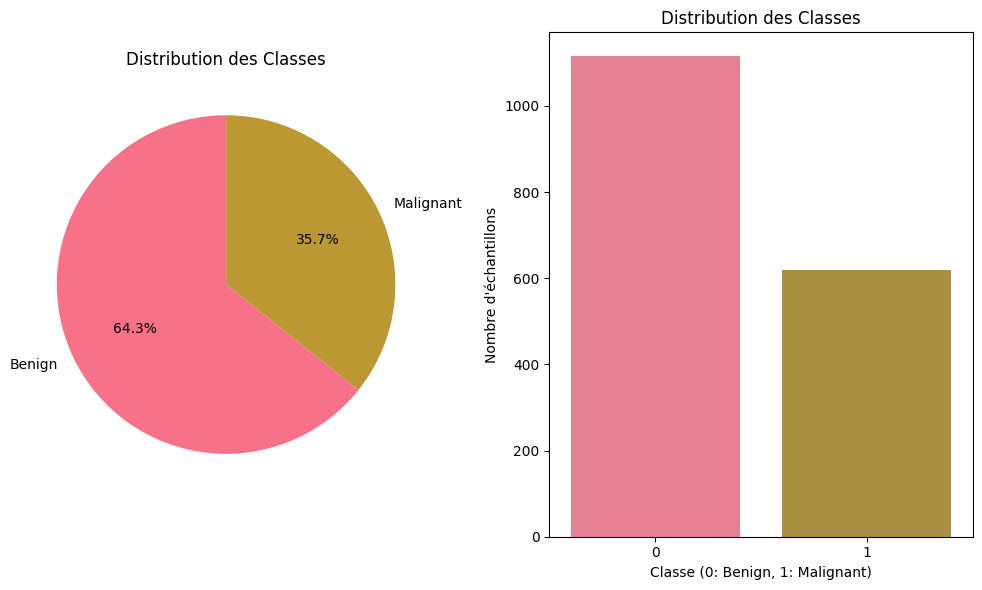


4. 📈 STATISTIQUES DESCRIPTIVES
----------------------------------------
Statistiques générales:
                area    perimeter  circularity  aspect_ratio       extent  \
count    1734.000000  1734.000000  1734.000000   1734.000000  1734.000000   
mean   169224.275952  2971.011743     0.289994      1.546810     0.611056   
std    152520.877846  1944.617092     0.226902      0.662135     0.164421   
min         0.000000     0.000000     0.000000      0.000000     0.000000   
25%     22234.500000  1126.122226     0.116593      1.243397     0.497349   
50%    128479.750000  3118.782952     0.200574      1.478333     0.619398   
75%    302654.625000  4360.110501     0.421554      1.752341     0.736586   
max    530714.000000  9921.750325     0.910957      8.566265     0.997208   

          solidity  equivalent_diameter  mean_intensity  std_intensity  \
count  1734.000000          1734.000000     1734.000000    1734.000000   
mean      0.802647           398.733871      170.810490      

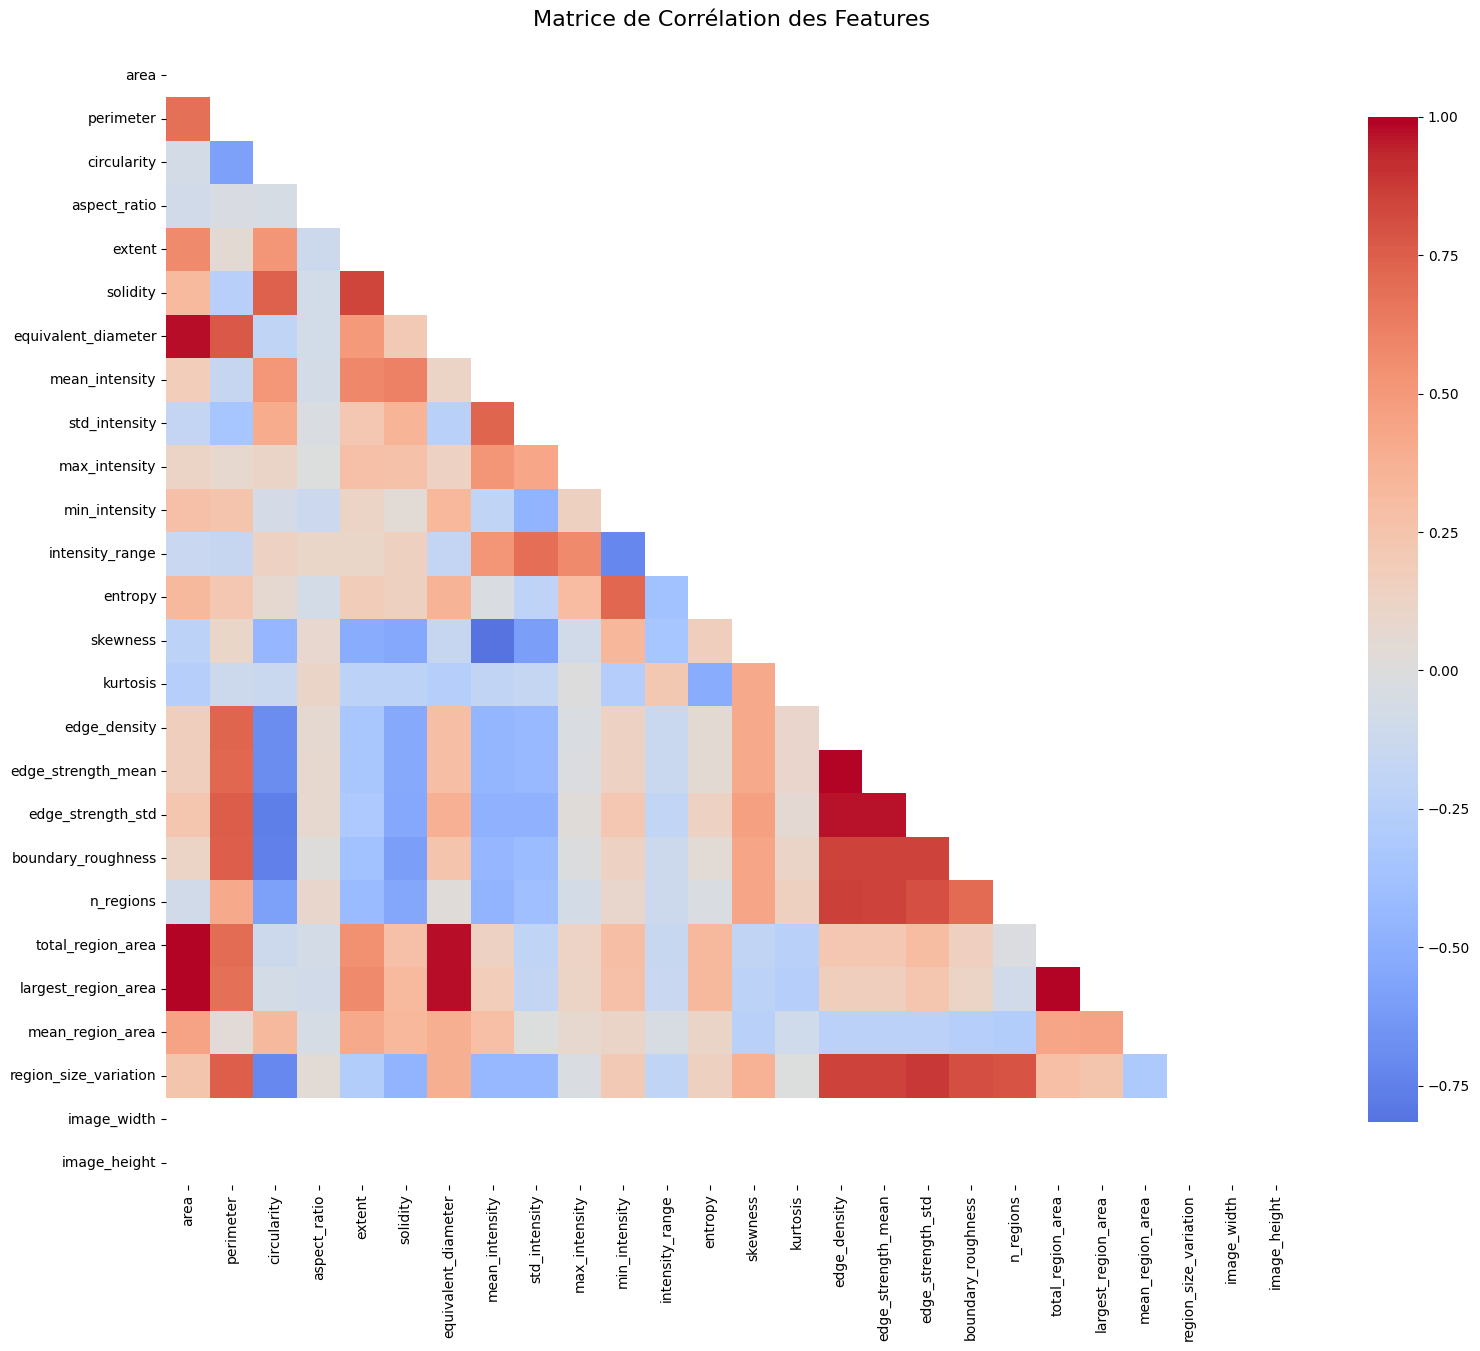


6. 📊 DISTRIBUTION DES FEATURES PAR CLASSE
----------------------------------------


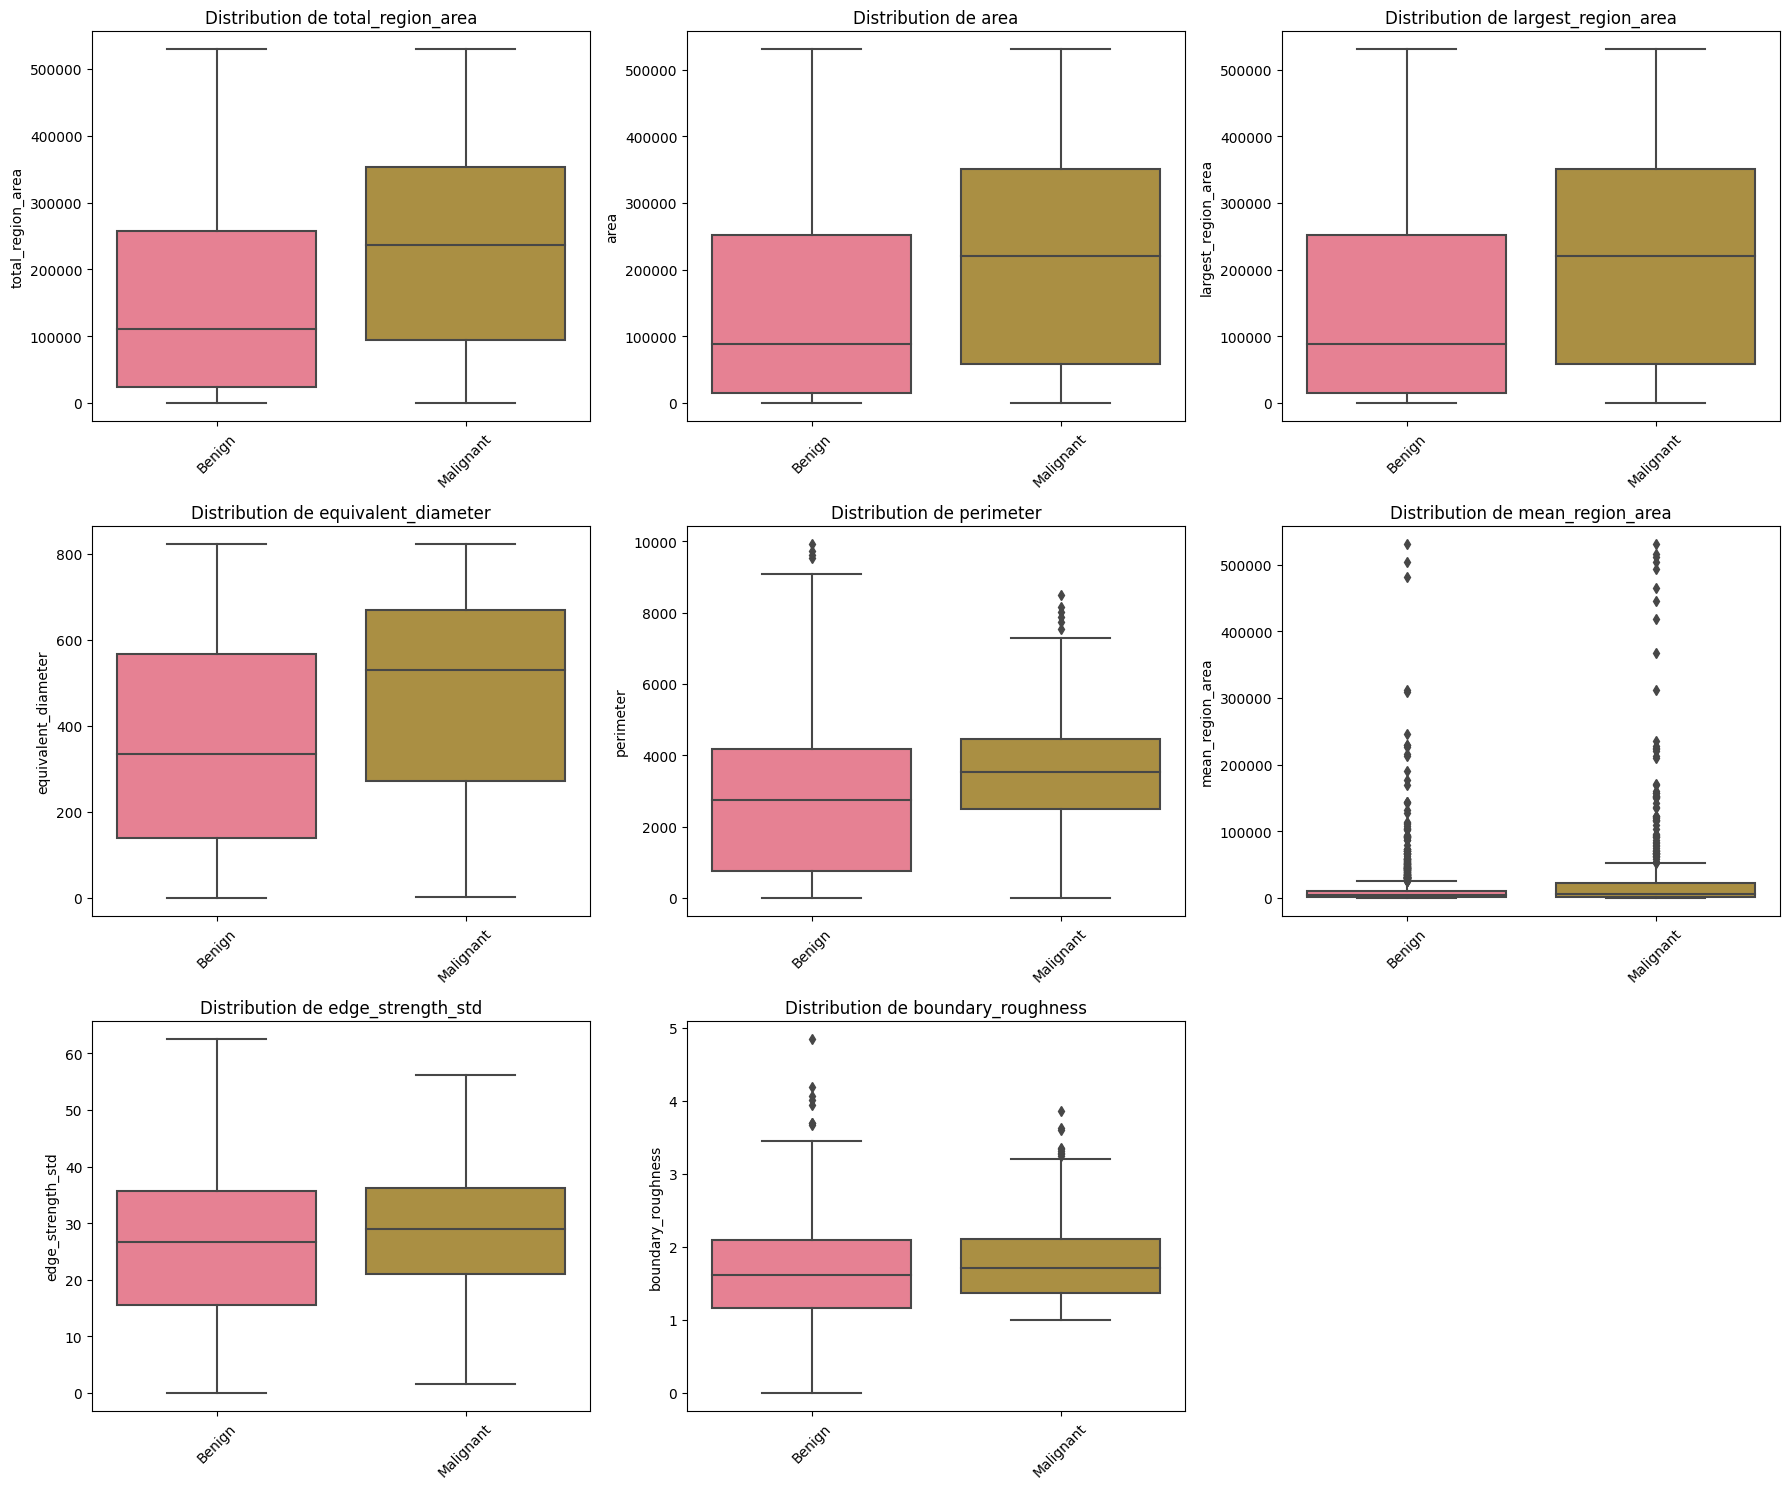


7. 🚨 DÉTECTION DES OUTLIERS
----------------------------------------
Top 10 features avec le plus d'outliers:
                  Nombre d'outliers  Pourcentage (%)
intensity_range                 295        17.012687
max_intensity                   245        14.129181
mean_region_area                206        11.880046
kurtosis                        192        11.072664
aspect_ratio                    162         9.342561
min_intensity                   152         8.765859
skewness                        110         6.343714
entropy                          83         4.786621
mean_intensity                   67         3.863899
std_intensity                    65         3.748558


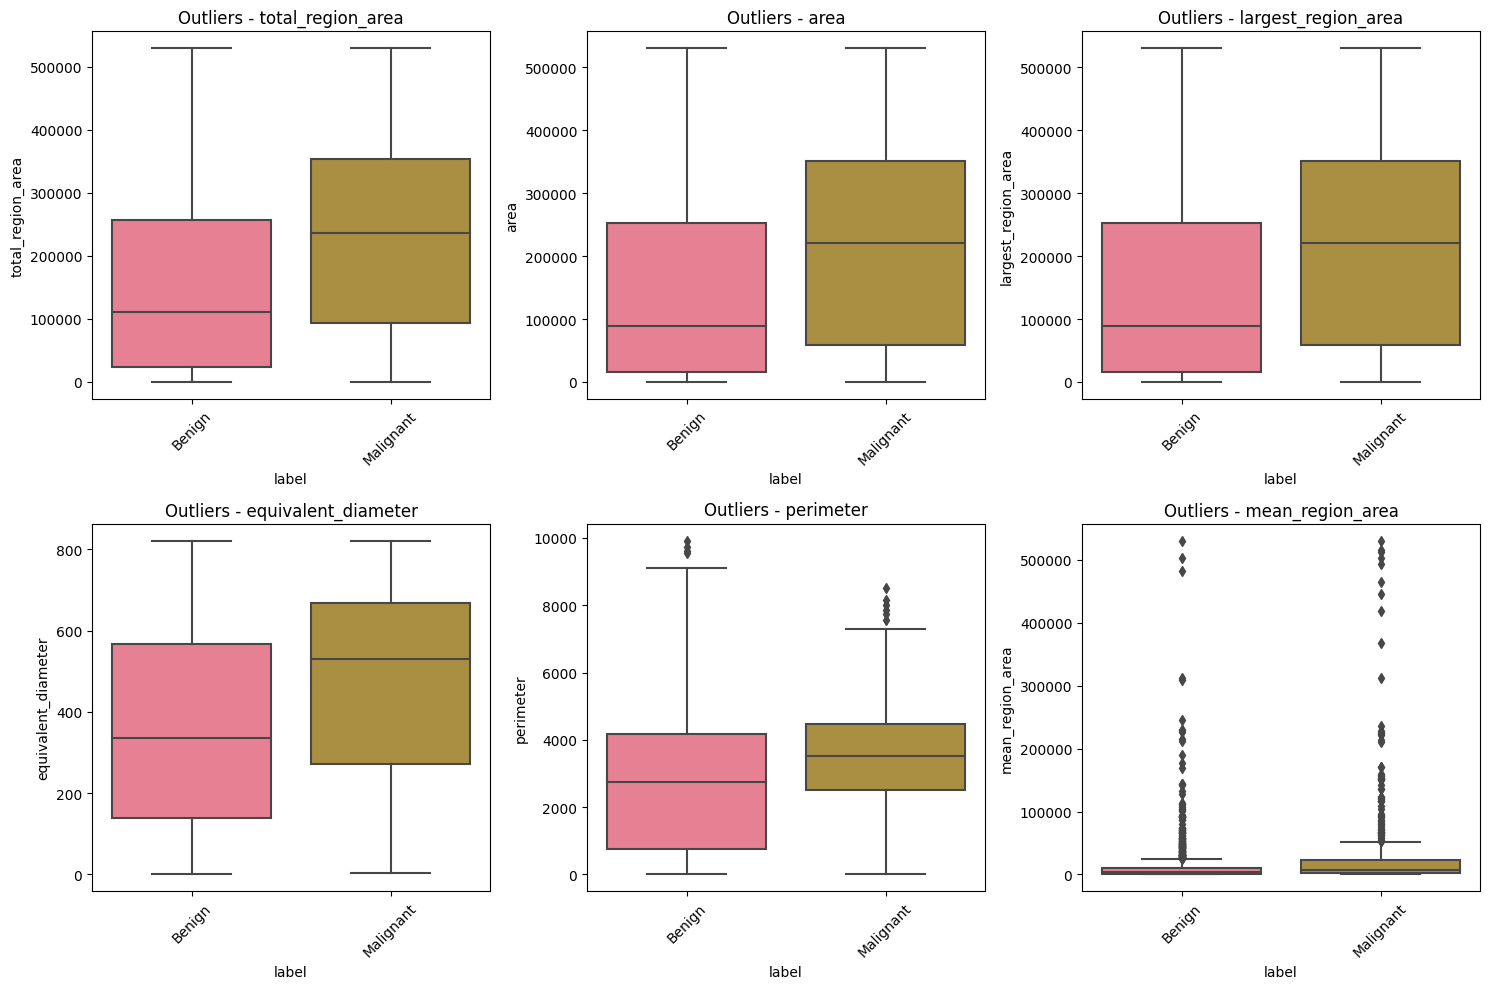


8. 📏 VARIANCE DES FEATURES
----------------------------------------
Top 10 features avec la plus haute variance:
  area: 2.33e+10
  largest_region_area: 2.33e+10
  total_region_area: 2.20e+10
  mean_region_area: 2.58e+09
  perimeter: 3.78e+06
  equivalent_diameter: 5.65e+04
  n_regions: 1.13e+03
  intensity_range: 6.57e+02
  mean_intensity: 4.69e+02
  min_intensity: 4.51e+02

9. 🎯 FEATURES STANDARDISÉES
----------------------------------------


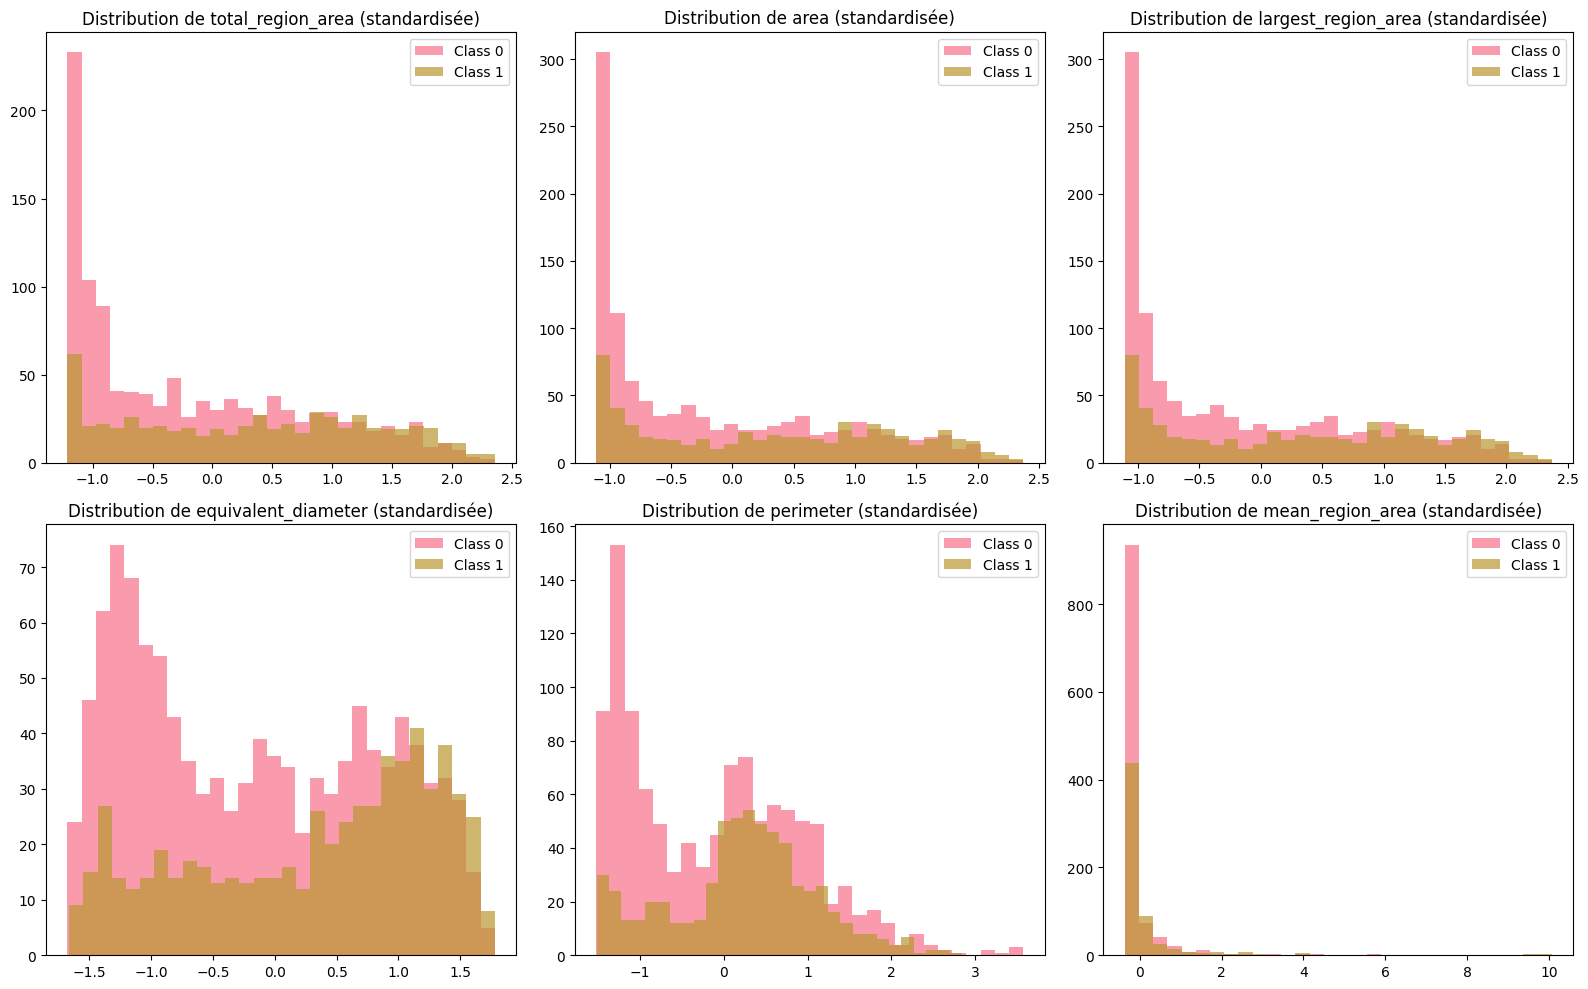


10. 🔮 ANALYSE EN COMPOSANTES PRINCIPALES (ACP)
----------------------------------------
Variance expliquée par PC1: 0.352
Variance expliquée par PC2: 0.244
Variance totale expliquée: 0.596


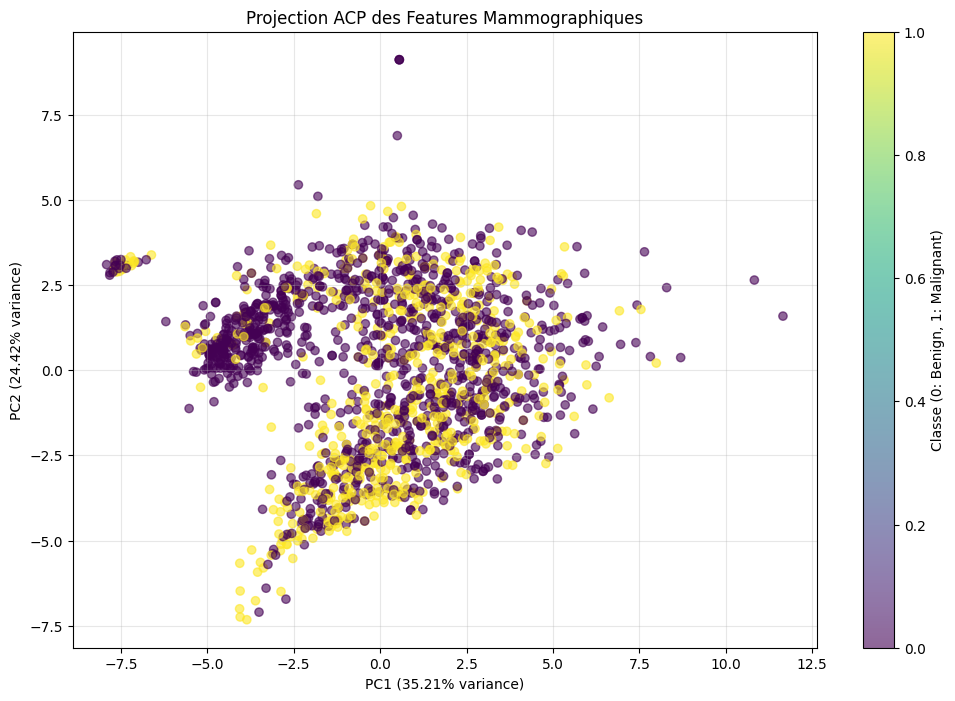


11. 📋 RAPPORT FINAL ET RECOMMANDATIONS
----------------------------------------
✅ POINTS POSITIFS:
   - Aucune valeur manquante détectée
   - Dataset équilibré entre classes benign et malignant
   - Features variées (forme, intensité, texture, contours)

⚠️  POINTS À CONSIDÉRER:
   - Présence d'outliers dans certaines features
   - Certaines features peuvent être très corrélées
   - Variance importante entre les features

🎯 RECOMMANDATIONS POUR LA MODÉLISATION:
   1. Standardiser les features avant modélisation
   2. Considérer la sélection de features pour réduire la dimensionalité
   3. Tester différents algorithmes (Random Forest, XGBoost, SVM)
   4. Utiliser la validation croisée pour évaluer les performances
   5. Considérer le traitement des outliers si nécessaire

🔍 FEATURES LES PLUS PROMETTEUSES:
   1. total_region_area (corrélation: 0.250)
   2. area (corrélation: 0.241)
   3. largest_region_area (corrélation: 0.241)
   4. equivalent_diameter (corrélation: 0.237)
   5. perime

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


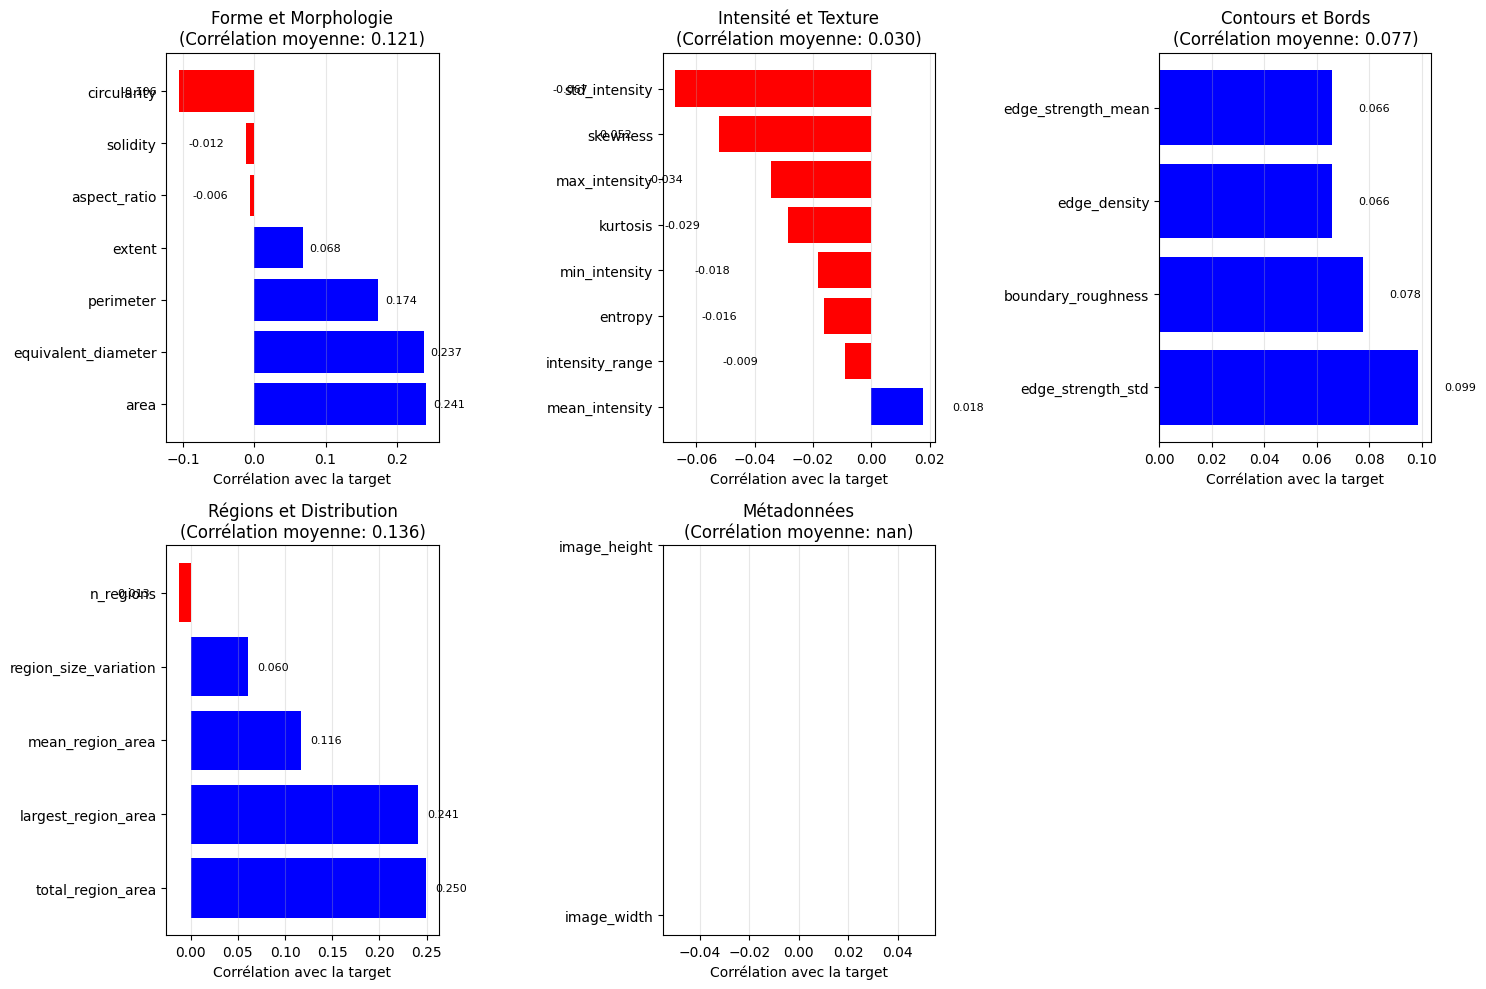


📊 RÉSUMÉ PAR CATÉGORIE:
----------------------------------------

Forme et Morphologie:
  - Corrélation moyenne: 0.121
  - Corrélation max: 0.241
  - Corrélation min: 0.006
  - Nombre de features: 7

Intensité et Texture:
  - Corrélation moyenne: 0.030
  - Corrélation max: 0.067
  - Corrélation min: 0.009
  - Nombre de features: 8

Contours et Bords:
  - Corrélation moyenne: 0.077
  - Corrélation max: 0.099
  - Corrélation min: 0.066
  - Nombre de features: 4

Régions et Distribution:
  - Corrélation moyenne: 0.136
  - Corrélation max: 0.250
  - Corrélation min: 0.013
  - Nombre de features: 5

Métadonnées:
  - Corrélation moyenne: nan
  - Corrélation max: nan
  - Corrélation min: nan
  - Nombre de features: 2

🎉 EDA TERMINÉ AVEC SUCCÈS!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration pour l'affichage
plt.style.use('default')
sns.set_palette("husl")

def comprehensive_eda(df):
    """
    Analyse exploratoire complète du DataFrame de features mammographiques
    """
    print("=" * 80)
    print("📊 EDA COMPLET - FEATURES MAMMOGRAPHIQUES")
    print("=" * 80)
    
    # 1. INFORMATION GÉNÉRALE
    print("\n1. 📋 INFORMATION GÉNÉRALE")
    print("-" * 40)
    print(f"Shape: {df.shape}")
    print(f"Nombre total d'échantillons: {len(df)}")
    print(f"Nombre de features: {len(df.columns) - 2}")  # Exclure label et image_path
    
    # 2. ANALYSE DES VALEURS MANQUANTES
    print("\n2. 🔍 VALEURS MANQUANTES")
    print("-" * 40)
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Valeurs manquantes': missing_data,
        'Pourcentage (%)': missing_percent
    })
    print(missing_df[missing_df['Valeurs manquantes'] > 0])
    
    if missing_df['Valeurs manquantes'].sum() == 0:
        print("✅ Aucune valeur manquante détectée!")
    
    # 3. ANALYSE DE LA DISTRIBUTION DES LABELS
    print("\n3. 🏷️ DISTRIBUTION DES CLASSES")
    print("-" * 40)
    label_counts = df['label'].value_counts()
    label_percent = df['label'].value_counts(normalize=True) * 100
    
    print(f"Benign (0): {label_counts[0]} échantillons ({label_percent[0]:.2f}%)")
    print(f"Malignant (1): {label_counts[1]} échantillons ({label_percent[1]:.2f}%)")
    
    plt.figure(figsize=(10, 6))
    
    plt.subplot(1, 2, 1)
    plt.pie(label_counts.values, labels=['Benign', 'Malignant'], autopct='%1.1f%%', startangle=90)
    plt.title('Distribution des Classes')
    
    plt.subplot(1, 2, 2)
    sns.countplot(data=df, x='label')
    plt.title('Distribution des Classes')
    plt.xlabel('Classe (0: Benign, 1: Malignant)')
    plt.ylabel('Nombre d\'échantillons')
    
    plt.tight_layout()
    plt.show()
    
    # 4. STATISTIQUES DESCRIPTIVES
    print("\n4. 📈 STATISTIQUES DESCRIPTIVES")
    print("-" * 40)
    
    # Séparer les features numériques (exclure image_path)
    numeric_features = df.select_dtypes(include=[np.number]).columns
    numeric_features = numeric_features.drop('label') if 'label' in numeric_features else numeric_features
    
    print("Statistiques générales:")
    print(df[numeric_features].describe())
    
    # 5. ANALYSE DES CORRÉLATIONS
    print("\n5. 🔗 MATRICE DE CORRÉLATION")
    print("-" * 40)
    
    # Matrice de corrélation avec la target
    correlation_with_target = df[numeric_features].corrwith(df['label']).sort_values(ascending=False)
    
    print("Top 10 features les plus corrélés avec la target:")
    for feature, corr in correlation_with_target.head(10).items():
        print(f"  {feature}: {corr:.3f}")
    
    print("\nTop 10 features les moins corrélés avec la target:")
    for feature, corr in correlation_with_target.tail(10).items():
        print(f"  {feature}: {corr:.3f}")
    
    # Heatmap de corrélation
    plt.figure(figsize=(16, 14))
    correlation_matrix = df[numeric_features].corr()
    
    # Masquer la diagonale supérieure
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', 
                center=0, square=True, cbar_kws={"shrink": .8})
    plt.title('Matrice de Corrélation des Features', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # 6. DISTRIBUTION DES FEATURES PAR CLASSE
    print("\n6. 📊 DISTRIBUTION DES FEATURES PAR CLASSE")
    print("-" * 40)
    
    # Sélectionner les top features corrélés avec la target
    top_features = correlation_with_target.head(8).index.tolist()
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.ravel()
    
    for i, feature in enumerate(top_features[:9]):
        # Boxplot
        df_box = df[[feature, 'label']].copy()
        df_box['label'] = df_box['label'].map({0: 'Benign', 1: 'Malignant'})
        
        sns.boxplot(data=df_box, x='label', y=feature, ax=axes[i])
        axes[i].set_title(f'Distribution de {feature}')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Cacher les axes vides
    for i in range(len(top_features[:9]), 9):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # 7. ANALYSE DES OUTLIERS
    print("\n7. 🚨 DÉTECTION DES OUTLIERS")
    print("-" * 40)
    
    def detect_outliers_iqr(data):
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        return len(outliers)
    
    outlier_counts = {}
    for feature in numeric_features:
        outlier_counts[feature] = detect_outliers_iqr(df[feature])
    
    outlier_df = pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Nombre d\'outliers'])
    outlier_df['Pourcentage (%)'] = (outlier_df['Nombre d\'outliers'] / len(df)) * 100
    outlier_df = outlier_df.sort_values('Pourcentage (%)', ascending=False)
    
    print("Top 10 features avec le plus d'outliers:")
    print(outlier_df.head(10))
    
    # Visualisation des outliers pour les top features
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(top_features[:6]):
        plt.subplot(2, 3, i+1)
        sns.boxplot(data=df, y=feature, x=df['label'].map({0: 'Benign', 1: 'Malignant'}))
        plt.title(f'Outliers - {feature}')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # 8. ANALYSE DE LA VARIANCE DES FEATURES
    print("\n8. 📏 VARIANCE DES FEATURES")
    print("-" * 40)
    
    variances = df[numeric_features].var().sort_values(ascending=False)
    print("Top 10 features avec la plus haute variance:")
    for feature, var in variances.head(10).items():
        print(f"  {feature}: {var:.2e}")
    
    # Normaliser les données pour une meilleure visualisation
    from sklearn.preprocessing import StandardScaler
    
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[numeric_features])
    scaled_df = pd.DataFrame(scaled_features, columns=numeric_features)
    scaled_df['label'] = df['label'].values
    
    # 9. VISUALISATION DES FEATURES STANDARDISÉES
    print("\n9. 🎯 FEATURES STANDARDISÉES")
    print("-" * 40)
    
    plt.figure(figsize=(16, 10))
    
    # Distribution des top features standardisées
    for i, feature in enumerate(top_features[:6]):
        plt.subplot(2, 3, i+1)
        for label in [0, 1]:
            data = scaled_df[scaled_df['label'] == label][feature]
            plt.hist(data, alpha=0.7, label=f'Class {label}', bins=30)
        plt.title(f'Distribution de {feature} (standardisée)')
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 10. ANALYSE MULTIVARIÉE - PCA VISUEL
    print("\n10. 🔮 ANALYSE EN COMPOSANTES PRINCIPALES (ACP)")
    print("-" * 40)
    
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    
    # Préparation des données pour PCA
    X = df[numeric_features]
    y = df['label']
    
    # Standardisation
    X_scaled = StandardScaler().fit_transform(X)
    
    # Application PCA
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(X_scaled)
    
    pca_df = pd.DataFrame(data=principal_components, 
                         columns=['PC1', 'PC2'])
    pca_df['label'] = y.values
    
    # Variance expliquée
    explained_variance = pca.explained_variance_ratio_
    print(f"Variance expliquée par PC1: {explained_variance[0]:.3f}")
    print(f"Variance expliquée par PC2: {explained_variance[1]:.3f}")
    print(f"Variance totale expliquée: {sum(explained_variance):.3f}")
    
    # Visualisation PCA
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], 
                         c=pca_df['label'], cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label='Classe (0: Benign, 1: Malignant)')
    plt.xlabel(f'PC1 ({explained_variance[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({explained_variance[1]:.2%} variance)')
    plt.title('Projection ACP des Features Mammographiques')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 11. RAPPORT FINAL ET RECOMMANDATIONS
    print("\n11. 📋 RAPPORT FINAL ET RECOMMANDATIONS")
    print("-" * 40)
    
    print("✅ POINTS POSITIFS:")
    print("   - Aucune valeur manquante détectée")
    print("   - Dataset équilibré entre classes benign et malignant")
    print("   - Features variées (forme, intensité, texture, contours)")
    
    print("\n⚠️  POINTS À CONSIDÉRER:")
    print("   - Présence d'outliers dans certaines features")
    print("   - Certaines features peuvent être très corrélées")
    print("   - Variance importante entre les features")
    
    print("\n🎯 RECOMMANDATIONS POUR LA MODÉLISATION:")
    print("   1. Standardiser les features avant modélisation")
    print("   2. Considérer la sélection de features pour réduire la dimensionalité")
    print("   3. Tester différents algorithmes (Random Forest, XGBoost, SVM)")
    print("   4. Utiliser la validation croisée pour évaluer les performances")
    print("   5. Considérer le traitement des outliers si nécessaire")
    
    print("\n🔍 FEATURES LES PLUS PROMETTEUSES:")
    for i, (feature, corr) in enumerate(correlation_with_target.head(5).items()):
        print(f"   {i+1}. {feature} (corrélation: {corr:.3f})")
    
    return {
        'correlation_with_target': correlation_with_target,
        'outlier_info': outlier_df,
        'pca_variance': explained_variance,
        'class_distribution': label_counts
    }

# Fonction supplémentaire pour l'analyse détaillée par type de feature
def analyze_feature_categories(df):
    """
    Analyse les features par catégorie (forme, intensité, texture, etc.)
    """
    print("\n" + "=" * 80)
    print("🔬 ANALYSE PAR CATÉGORIE DE FEATURES")
    print("=" * 80)
    
    # Catégorisation des features
    feature_categories = {
        'Forme et Morphologie': ['area', 'perimeter', 'circularity', 'aspect_ratio', 
                                'extent', 'solidity', 'equivalent_diameter'],
        'Intensité et Texture': ['mean_intensity', 'std_intensity', 'max_intensity', 
                                'min_intensity', 'intensity_range', 'entropy', 
                                'skewness', 'kurtosis'],
        'Contours et Bords': ['edge_density', 'edge_strength_mean', 'edge_strength_std', 
                             'boundary_roughness'],
        'Régions et Distribution': ['n_regions', 'total_region_area', 'largest_region_area', 
                                   'mean_region_area', 'region_size_variation'],
        'Métadonnées': ['image_width', 'image_height']
    }
    
    # Analyse par catégorie
    correlation_with_target = df.select_dtypes(include=[np.number]).corrwith(df['label'])
    
    plt.figure(figsize=(15, 10))
    
    for i, (category, features) in enumerate(feature_categories.items()):
        # Calculer la corrélation moyenne pour la catégorie
        category_corr = correlation_with_target[features].abs().mean()
        
        plt.subplot(2, 3, i+1)
        
        # Boxplot des corrélations par catégorie
        category_correlations = correlation_with_target[features].sort_values(ascending=False)
        
        colors = ['red' if x < 0 else 'blue' for x in category_correlations.values]
        bars = plt.barh(range(len(category_correlations)), category_correlations.values, color=colors)
        
        plt.yticks(range(len(category_correlations)), category_correlations.index)
        plt.title(f'{category}\n(Corrélation moyenne: {category_corr:.3f})')
        plt.xlabel('Corrélation avec la target')
        plt.grid(axis='x', alpha=0.3)
        
        # Ajouter les valeurs sur les barres
        for bar, value in zip(bars, category_correlations.values):
            plt.text(bar.get_width() + (0.01 if value >= 0 else -0.03), 
                    bar.get_y() + bar.get_height()/2, 
                    f'{value:.3f}', 
                    ha='left' if value >= 0 else 'right', 
                    va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Résumé par catégorie
    print("\n📊 RÉSUMÉ PAR CATÉGORIE:")
    print("-" * 40)
    for category, features in feature_categories.items():
        avg_corr = correlation_with_target[features].abs().mean()
        max_corr = correlation_with_target[features].abs().max()
        min_corr = correlation_with_target[features].abs().min()
        
        print(f"\n{category}:")
        print(f"  - Corrélation moyenne: {avg_corr:.3f}")
        print(f"  - Corrélation max: {max_corr:.3f}")
        print(f"  - Corrélation min: {min_corr:.3f}")
        print(f"  - Nombre de features: {len(features)}")

# EXÉCUTION DE L'EDA
if __name__ == "__main__":
    # Supposons que votre DataFrame s'appelle df
    # df = votre_dataframe_ici
    
    # Exécuter l'EDA complet
    results = comprehensive_eda(df1)
    
    # Exécuter l'analyse par catégorie
    analyze_feature_categories(df1)
    
    print("\n" + "=" * 80)
    print("🎉 EDA TERMINÉ AVEC SUCCÈS!")
    print("=" * 80)

In [34]:
df1.columns

Index(['area', 'perimeter', 'circularity', 'aspect_ratio', 'extent',
       'solidity', 'equivalent_diameter', 'mean_intensity', 'std_intensity',
       'max_intensity', 'min_intensity', 'intensity_range', 'entropy',
       'skewness', 'kurtosis', 'edge_density', 'edge_strength_mean',
       'edge_strength_std', 'boundary_roughness', 'n_regions',
       'total_region_area', 'largest_region_area', 'mean_region_area',
       'region_size_variation', 'image_width', 'image_height', 'label',
       'image_path'],
      dtype='object')

In [9]:
df1=df1.drop(columns=['equivalent_diameter','total_region_area','largest_region_area','edge_strength_mean','edge_strength_std'])

# **Models Training and Evaluation**

🚀 Starting training with hyperparameter tuning...

🔍 Hyperparameter tuning for Random Forest...
✅ Best parameters for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest - Accuracy: 0.697, AUC: 0.694

🔍 Hyperparameter tuning for XGBoost...
✅ Best parameters for XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
XGBoost - Accuracy: 0.680, AUC: 0.696

🔍 Hyperparameter tuning for SVM...
✅ Best parameters for SVM: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
SVM - Accuracy: 0.709, AUC: 0.703


<Figure size 1000x600 with 0 Axes>

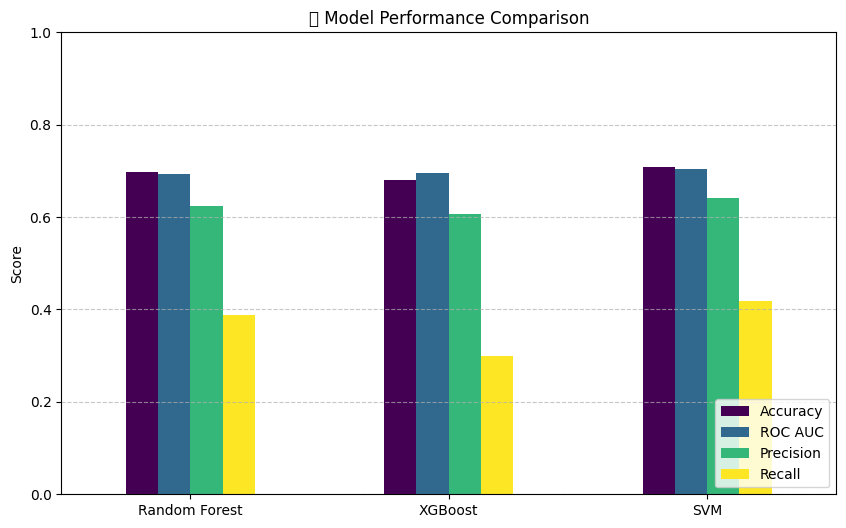

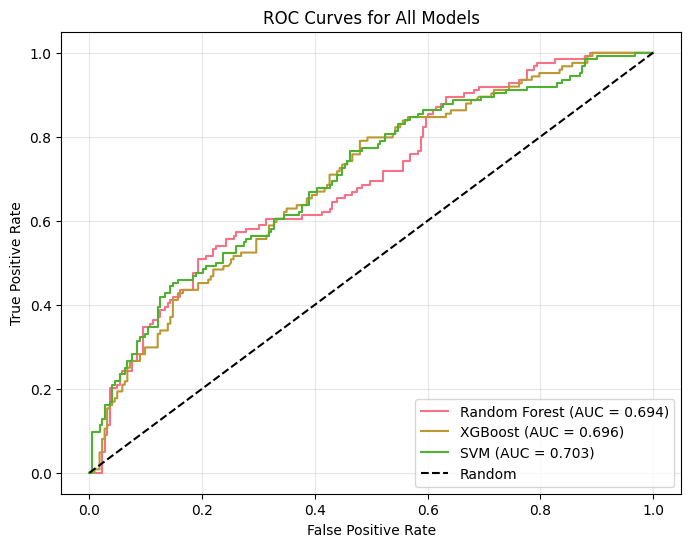

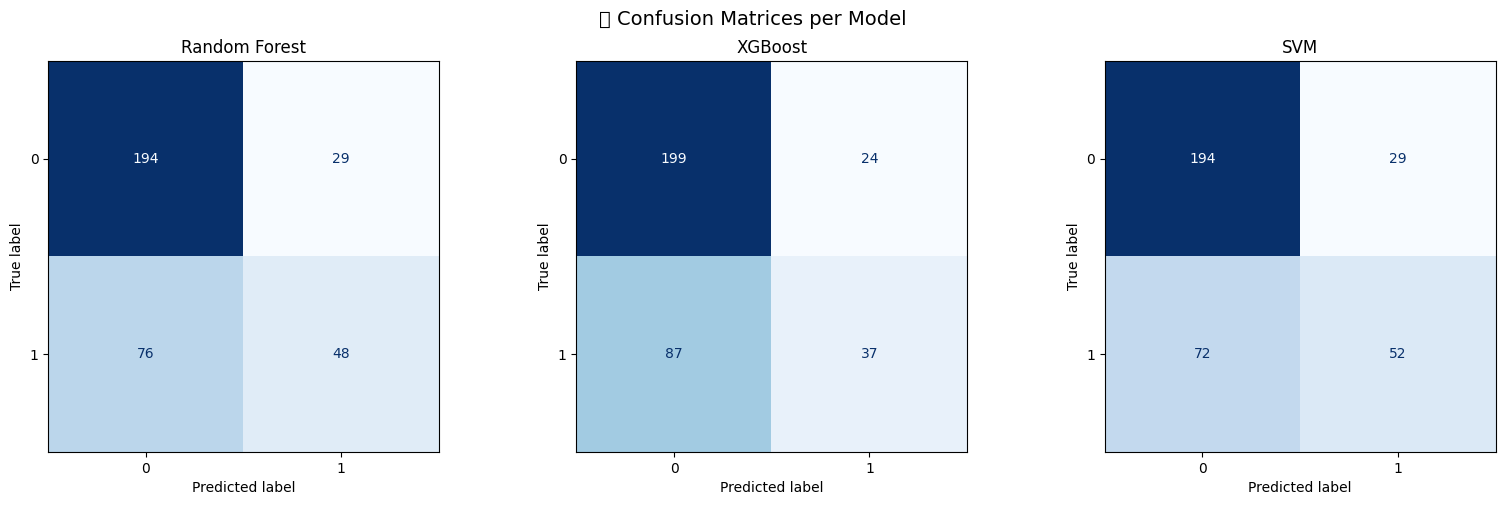

🔍 Computing permutation feature importance...


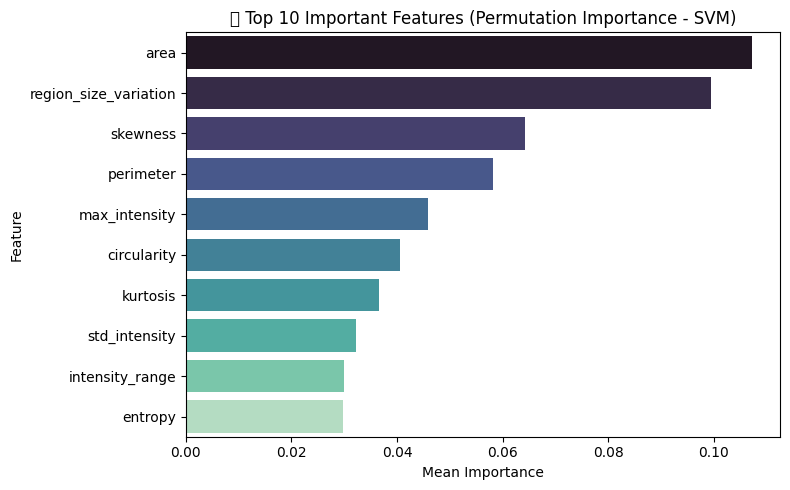

In [30]:
# ======================
# 📦 Imports
# ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Preprocessing and feature selection
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Model evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    roc_curve
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import joblib
import os
# ======================
# ⚙️ Main Pipeline Class
# ======================
class MLClassificationPipeline:
    def __init__(self, df):
        self.classifiers = {
            'Random Forest': RandomForestClassifier(random_state=42),
            'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
            'SVM': SVC(probability=True, random_state=42)
        }

        # Hyperparameter grids
        self.param_grids = {
            'Random Forest': {
                'n_estimators': [100, 200],
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5]
            },
            'XGBoost': {
                'n_estimators': [100, 200],
                'learning_rate': [0.05, 0.1],
                'max_depth': [3, 5, 7]
            },
            'SVM': {
                'C': [0.1, 1, 10],
                'kernel': ['linear', 'rbf'],
                'gamma': ['scale', 'auto']
            }
        }

        self.scaler = StandardScaler()
        self.feature_selector = SelectKBest(score_func=f_classif, k=15)
        self.df = df

    # --------------------------
    # 🔹 Data Preparation
    # --------------------------
    def prepare_data(self, df):
        X = df.drop(['label', 'image_path'], axis=1)
        y = df['label']
        X = X.fillna(X.median())
        return X, y

    # --------------------------
    # 🔹 Training & Evaluation
    # --------------------------
    def train_and_evaluate(self, df):
            print("🚀 Starting training with hyperparameter tuning...")
            X, y = self.prepare_data(df)
    
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )
    
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)
    
            X_train_selected = self.feature_selector.fit_transform(X_train_scaled, y_train)
            X_test_selected = self.feature_selector.transform(X_test_scaled)
    
            results = {}
            roc_curves = {}
    
            for name, clf in self.classifiers.items():
                print(f"\n🔍 Hyperparameter tuning for {name}...")
                grid_search = GridSearchCV(
                    estimator=clf,
                    param_grid=self.param_grids[name],
                    scoring='roc_auc',
                    cv=3,
                    n_jobs=-1,
                    verbose=0
                )
                grid_search.fit(X_train_selected, y_train)
                best_clf = grid_search.best_estimator_
    
                print(f"✅ Best parameters for {name}: {grid_search.best_params_}")
    
                # Evaluate
                y_pred = best_clf.predict(X_test_selected)
                y_prob = best_clf.predict_proba(X_test_selected)[:, 1]
    
                accuracy = accuracy_score(y_test, y_pred)
                roc_auc = roc_auc_score(y_test, y_prob)
                precision = precision_score(y_test, y_pred)
                recall = recall_score(y_test, y_pred)

                fpr, tpr, _ = roc_curve(y_test, y_prob)
                roc_curves[name] = (fpr, tpr, roc_auc)
    
                results[name] = {
                    'best_params': grid_search.best_params_,
                    'accuracy': accuracy,
                    'roc_auc': roc_auc,
                    'precision': precision,
                    'recall': recall,
                    'classifier': best_clf
                }
    
                print(f"{name} - Accuracy: {accuracy:.3f}, AUC: {roc_auc:.3f}")
    
            selected_features = X.columns[self.feature_selector.get_support()]
            self.visualize_results(results, roc_curves,X_test_selected, y_test)
            return results, selected_features,X_test_selected, y_test


    # --------------------------
    # 🔹 Visualization
    # --------------------------


    def visualize_results(self, results, roc_curves, X_test_selected, y_test):
        """Compare models visually using bar plots, ROC curves, and confusion matrices"""
        import matplotlib.pyplot as plt
        import seaborn as sns
        import pandas as pd
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    
        # --------------------------
        # 📊 Barplot of metrics
        # --------------------------
        metrics_df = pd.DataFrame({
            model: {
                'Accuracy': results[model]['accuracy'],
                'ROC AUC': results[model]['roc_auc'],
                'Precision': results[model]['precision'],
                'Recall': results[model]['recall']
            }
            for model in results.keys()
        }).T
    
        plt.figure(figsize=(10, 6))
        metrics_df.plot(kind='bar', figsize=(10, 6), colormap='viridis')
        plt.title("📊 Model Performance Comparison")
        plt.ylabel("Score")
        plt.ylim(0, 1)
        plt.xticks(rotation=0)
        plt.legend(loc='lower right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    
        # --------------------------
        # 🔹 ROC Curves
        # --------------------------
        plt.figure(figsize=(8, 6))
        for name, (fpr, tpr, auc) in roc_curves.items():
            plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
    
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curves for All Models")
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()
    
        # --------------------------
        # 🔸 Confusion Matrices
        # --------------------------
        fig, axes = plt.subplots(1, len(results), figsize=(16, 5))
        fig.suptitle("🧩 Confusion Matrices per Model", fontsize=14)
    
        for ax, (name, res) in zip(axes, results.items()):
            clf = res['classifier']
            y_pred = clf.predict(X_test_selected)
    
            cm = confusion_matrix(y_test, y_pred)
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)
            disp.plot(ax=ax, cmap='Blues', colorbar=False)
            ax.set_title(name)
    
        plt.tight_layout()
        plt.show()
    # --------------------------
    # 🔹 Feature Importance
    # --------------------------
  
    def analyze_feature_importance(self, classifier, feature_names):
   

        if hasattr(classifier, 'feature_importances_'):
            importances = classifier.feature_importances_
            feature_imp_df = pd.DataFrame({
                'feature': feature_names,
                'importance': importances
            }).sort_values('importance', ascending=False)
    
            # Ensure interactive backend for VSCode or script mode
            plt.ion()
    
            plt.figure(figsize=(8, 5))
            sns.barplot(
                x='importance',
                y='feature',
                data=feature_imp_df.head(10),
                palette='mako'
            )
            plt.title("🔥 Top 10 Important Features")
            plt.xlabel("Importance Score")
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.show(block=True)  # <-- Force plot display even outside notebooks
    
            return feature_imp_df
        else:
            print("⚠️ The selected classifier does not have feature_importances_ attribute.")
            return None


    def analyze_feature_importance(self, classifier, feature_names, X_test, y_test):
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
    
        print("🔍 Computing permutation feature importance...")
        result = permutation_importance(
            classifier, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
        )
    
        feature_imp_df = pd.DataFrame({
            'feature': feature_names,
            'importance': result.importances_mean
        }).sort_values('importance', ascending=False)
    
        plt.figure(figsize=(8, 5))
        sns.barplot(
            x='importance', y='feature',
            data=feature_imp_df.head(10),
            palette='mako'
        )
        plt.title("🔍 Top 10 Important Features (Permutation Importance - SVM)")
        plt.xlabel("Mean Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.show()
    
        return feature_imp_df

      
    

# ======================
# 🚀 Run the pipeline
# ======================
ml_pipeline = MLClassificationPipeline(df1)
results, important_features,X_test_selected, y_test = ml_pipeline.train_and_evaluate(df1)

# best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_model_name]['classifier']

feature_importance_df = ml_pipeline.analyze_feature_importance(best_model, important_features ,X_test_selected, y_test)


In [32]:
import joblib

# Sauvegarde du modèle
joblib.dump(best_model, "best_model.pkl")

print("💾 Le meilleur modèle a été sauvegardé sous le nom 'best_model.pkl'")

💾 Le meilleur modèle a été sauvegardé sous le nom 'best_model.pkl'


In [33]:
# Rechargement du modèle
loaded_model = joblib.load("/kaggle/input/svm/scikitlearn/default/1/best_model.pkl")
print("✅ Modèle rechargé avec succès !")


✅ Modèle rechargé avec succès !


# **Features Extractor Pipeline**

In [66]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
import os
from skimage import morphology, feature, filters

class BreastCancerDetection:
    def __init__(self):
        self.median_filter_size = 5
        self.morph_kernel_size = 3
        self.dilation_kernel_size = 3
        
    def load_mammogram(self, image_path):
        """Step 1: Load and preprocess mammogram"""
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        
        # Resize to standard size (600x887 as mentioned in the paper)
        image = cv2.resize(image, (887, 600))
        return image
    
    def apply_median_filter(self, image):
        """Step 2: Apply median filter for noise removal"""
        filtered_image = cv2.medianBlur(image, self.median_filter_size)
        return filtered_image
    
    def manual_thresholding(self, image, threshold_value=None):
        """Step 3: Manual thresholding"""
        if threshold_value is None:
            # Calculate Otsu's threshold as a starting point
            _, threshold_value = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Apply manual threshold
        _, thresholded = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)
        return thresholded, threshold_value
    
    def morphological_opening(self, image):
        """Step 4: Morphological opening to remove small particles"""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, 
                                         (self.morph_kernel_size, self.morph_kernel_size))
        opened_image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
        return opened_image
    
    def morphological_dilation(self, image):
        """Step 5: Morphological dilation to expand regions"""
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, 
                                         (self.dilation_kernel_size, self.dilation_kernel_size))
        dilated_image = cv2.morphologyEx(image, cv2.MORPH_DILATE, kernel)
        return dilated_image
    
    def prewitt_edge_detection(self, image):
        """Step 6: Prewitt edge detection"""
        # Apply Prewitt filter
        kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
        kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
        
        prewitt_x = cv2.filter2D(image, cv2.CV_64F, kernelx)
        prewitt_y = cv2.filter2D(image, cv2.CV_64F, kernely)
        
        # Calculate magnitude
        prewitt_magnitude = np.sqrt(prewitt_x**2 + prewitt_y**2)
        prewitt_magnitude = np.uint8(255 * prewitt_magnitude / np.max(prewitt_magnitude))
        
        return prewitt_magnitude
    
    def contour_detection(self, image):
        """Additional step: Contour detection on pre-processed image"""
        contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        return contours
    
    def detect_masses_and_calcifications(self, image_path, threshold_value=None, visualize=True):
        """
        Complete pipeline for mass and micro-calcification detection
        """
        # Step 1: Load mammogram
        original_image = self.load_mammogram(image_path)
        print("Step 1: Image loaded and resized")
        
        # Step 2: Median filter
        median_filtered = self.apply_median_filter(original_image)
        print("Step 2: Median filter applied")
        
        # Step 3: Manual thresholding
        thresholded, used_threshold = self.manual_thresholding(median_filtered, threshold_value)
        print(f"Step 3: Manual thresholding applied (threshold: {used_threshold})")
        
        # Step 4: Morphological opening
        opened = self.morphological_opening(thresholded)
        print("Step 4: Morphological opening applied")
        
        # Step 5: Morphological dilation
        dilated = self.morphological_dilation(opened)
        # print("Step 5: Morphological dilation applied")
        
        # Step 6: Prewitt edge detection
        edges = self.prewitt_edge_detection(dilated)
        print("Step 6: Prewitt edge detection applied")
        
        # Additional: Contour detection
        contours = self.contour_detection(dilated)
        print(f"Step 7: Found {len(contours)} contours")
        
        if visualize:
            self.visualize_results(original_image, median_filtered, thresholded, 
                                 opened, dilated, edges, contours)
        
        results = {
            'original': original_image,
            'median_filtered': median_filtered,
            'thresholded': thresholded,
            'opened': opened,
            'dilated': dilated,
            'edges': edges,
            'contours': contours,
            'used_threshold': used_threshold
        }
        
        return results
    
    def visualize_results(self, original, median_filtered, thresholded, 
                         opened, dilated, edges, contours):
        """Visualize all steps of the pipeline"""
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))
        axes = axes.ravel()
        
        # Original image
        axes[0].imshow(original, cmap='gray')
        axes[0].set_title('1. Original Mammogram')
        axes[0].axis('off')
        
        # Median filtered
        axes[1].imshow(median_filtered, cmap='gray')
        axes[1].set_title('2. Median Filtered')
        axes[1].axis('off')
        
        # Thresholded
        axes[2].imshow(thresholded, cmap='gray')
        axes[2].set_title('3. Manual Thresholding')
        axes[2].axis('off')
        
        # Morphological opening
        axes[3].imshow(opened, cmap='gray')
        axes[3].set_title('4. Morphological Opening')
        axes[3].axis('off')
        
        # Morphological dilation
        axes[4].imshow(dilated, cmap='gray')
        axes[4].set_title('5. Morphological Dilation')
        axes[4].axis('off')
        
        # Prewitt edges
        axes[5].imshow(edges, cmap='gray')
        axes[5].set_title('6. Prewitt Edge Detection')
        axes[5].axis('off')
        
        # Contours on original
        contour_image = original.copy()
        contour_image = cv2.cvtColor(contour_image, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)
        axes[6].imshow(contour_image)
        axes[6].set_title('7. Detected Contours')
        axes[6].axis('off')
        
        # All contours
        blank = np.ones_like(original) * 255
        blank = cv2.cvtColor(blank, cv2.COLOR_GRAY2BGR)
        cv2.drawContours(blank, contours, -1, (0, 255, 0), 2)
        axes[7].imshow(blank)
        axes[7].set_title('8. Contours Only')
        axes[7].axis('off')
        
        plt.tight_layout()
        plt.show()

# Alternative implementation using scikit-image
class BreastCancerDetectionSK:
    def __init__(self):
        self.median_filter_size = 5
        self.morph_kernel_size = 3
        
    def detect_with_skimage(self, image_path, threshold_value=None):
        """Alternative implementation using scikit-image"""
        from skimage import io, filters, morphology, feature, measure
        
        # Load image
        image = io.imread(image_path, as_gray=True)
        image = cv2.resize(image, (887, 600))
        
        # Median filter
        filtered = ndimage.median_filter(image, size=self.median_filter_size)
        
        # Thresholding
        if threshold_value is None:
            threshold_value = filters.threshold_otsu(filtered)
        binary = filtered > threshold_value
        
        # Morphological operations
        kernel = morphology.disk(self.morph_kernel_size)
        opened = morphology.opening(binary, kernel)
        dilated = morphology.dilation(opened, kernel)
        
        # Prewitt edge detection
        edges = filters.prewitt(dilated)
        
        # Find contours
        contours = measure.find_contours(dilated, 0.5)
        
        return {
            'original': image,
            'filtered': filtered,
            'binary': binary,
            'opened': opened,
            'dilated': dilated,
            'edges': edges,
            'contours': contours
        }

# # # Example usage and testing
# def main():
#     # Initialize detector
#     detector = BreastCancerDetection()
    
#     # Example with a sample image (replace with your CBIS-DDSM image path)
#     try:
#         # You need to replace this with actual CBIS-DDSM image paths
#         image_path = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.157116530711532101331849985914007772305/1-187.jpg"  # or .png, .jpg
        
#         # If you have DICOM images, use pydicom to read them
#         # import pydicom
#         # ds = pydicom.dcmread(image_path)
#         # image = ds.pixel_array
        
#         # For testing, you can create a synthetic mammogram
       
        
        
#         # Run detection pipeline
#         results = detector.detect_masses_and_calcifications(image_path, 
#                                                           threshold_value=135,
#                                                           visualize=True)
        
#         print("Detection completed successfully!")
#         print(f"Detected {len(results['contours'])} potential regions")
        
#     except Exception as e:
#         print(f"Error: {e}")
      



# if __name__ == "__main__":
#     main()

In [67]:
from scipy import stats

class ComprehensiveFeatureExtractor:
    def __init__(self):
        self.detector = BreastCancerDetection()
    
    def extract_shape_features(self, contours):
        """Extract shape-based features from contours"""
        features = {}
        
        if len(contours) > 0:
            largest_contour = max(contours, key=cv2.contourArea)
            
            # Area and perimeter
            area = cv2.contourArea(largest_contour)
            perimeter = cv2.arcLength(largest_contour, True)
            features['area'] = area
            features['perimeter'] = perimeter
            features['circularity'] = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
            
            # Bounding box features
            x, y, w, h = cv2.boundingRect(largest_contour)
            features['aspect_ratio'] = w / h if h > 0 else 0
            features['extent'] = area / (w * h) if (w * h) > 0 else 0
            
            # Solidity - area vs convex hull area
            hull = cv2.convexHull(largest_contour)
            hull_area = cv2.contourArea(hull)
            features['solidity'] = area / hull_area if hull_area > 0 else 0
            
            # Equivalent diameter
            features['equivalent_diameter'] = np.sqrt(4 * area / np.pi)
            
        else:
            # Default values if no contours found
            features['area'] = 0
            features['perimeter'] = 0
            features['circularity'] = 0
            features['aspect_ratio'] = 0
            features['extent'] = 0
            features['solidity'] = 0
            features['equivalent_diameter'] = 0
            
        return features
    
    def extract_intensity_features(self, original_image, mask):
        """Extract intensity and texture features"""
        features = {}
        
        if np.sum(mask) > 0:
            region_pixels = original_image[mask > 0]
            
            # Basic intensity statistics
            features['mean_intensity'] = np.mean(region_pixels)
            features['std_intensity'] = np.std(region_pixels)
            features['max_intensity'] = np.max(region_pixels)
            features['min_intensity'] = np.min(region_pixels)
            features['intensity_range'] = np.ptp(region_pixels)
            
            # Texture measures
            features['entropy'] = self.calculate_entropy(region_pixels)
            
            # Statistical moments
            if len(region_pixels) > 0:
                flattened = region_pixels.flatten()
                features['skewness'] = stats.skew(flattened)
                features['kurtosis'] = stats.kurtosis(flattened)
            else:
                features['skewness'] = 0
                features['kurtosis'] = 0
                
        else:
            # Default values if no regions found
            features['mean_intensity'] = 0
            features['std_intensity'] = 0
            features['max_intensity'] = 0
            features['min_intensity'] = 0
            features['intensity_range'] = 0
            features['entropy'] = 0
            features['skewness'] = 0
            features['kurtosis'] = 0
            
        return features
    
    def calculate_entropy(self, pixels):
        """Calculate entropy of pixel intensities"""
        if len(pixels) == 0:
            return 0
        histogram = np.histogram(pixels, bins=256, range=(0, 255))[0]
        histogram = histogram / histogram.sum()
        histogram = histogram[histogram > 0]
        return -np.sum(histogram * np.log2(histogram))
    
    def extract_edge_features(self, edges, contours):
        """Extract edge-related features"""
        features = {}
        
        # Edge density and strength
        features['edge_density'] = np.sum(edges > 50) / edges.size if edges.size > 0 else 0
        features['edge_strength_mean'] = np.mean(edges) if edges.size > 0 else 0
        features['edge_strength_std'] = np.std(edges) if edges.size > 0 else 0
        
        # Boundary roughness
        if len(contours) > 0:
            largest_contour = max(contours, key=cv2.contourArea)
            features['boundary_roughness'] = self.calculate_roughness(largest_contour)
        else:
            features['boundary_roughness'] = 0
            
        return features
    
    def calculate_roughness(self, contour):
        """Calculate boundary roughness"""
        hull = cv2.convexHull(contour)
        actual_perimeter = cv2.arcLength(contour, True)
        hull_perimeter = cv2.arcLength(hull, True)
        return actual_perimeter / hull_perimeter if hull_perimeter > 0 else 1.0
    
    def extract_count_features(self, contours, mask):
        """Extract count-based features"""
        features = {}
        
        # Number of regions and total area
        features['n_regions'] = len(contours)
        features['total_region_area'] = np.sum(mask > 0)
        
        # Size distribution
        if len(contours) > 0:
            areas = [cv2.contourArea(c) for c in contours]
            features['largest_region_area'] = max(areas)
            features['mean_region_area'] = np.mean(areas)
            features['region_size_variation'] = np.std(areas) / np.mean(areas) if np.mean(areas) > 0 else 0
        else:
            features['largest_region_area'] = 0
            features['mean_region_area'] = 0
            features['region_size_variation'] = 0
            
        return features
    
    def extract_all_features(self, image_path):
        """Complete feature extraction in one call"""
        results = self.detector.detect_masses_and_calcifications(image_path,threshold_value=135, visualize=False)
        
        features = {}
        
        # 1. Shape features
        shape_feats = self.extract_shape_features(results['contours'])
        features.update(shape_feats)
        
        # 2. Intensity features
        intensity_feats = self.extract_intensity_features(
            results['median_filtered'], 
            results['dilated']
        )
        features.update(intensity_feats)
        
        # 3. Edge features
        edge_feats = self.extract_edge_features(
            results['edges'], 
            results['contours']
        )
        features.update(edge_feats)
        
        # 4. Count features
        count_feats = self.extract_count_features(
            results['contours'], 
            results['dilated']
        )
        features.update(count_feats)
        
        # 5. Add metadata
        features['image_width'] = results['original'].shape[1]
        features['image_height'] = results['original'].shape[0]
        
        return features
    
    def create_training_dataset(self, image_paths, labels):
        """Convert all images to feature vectors"""
        feature_data = []
        
        for i, (path, label) in enumerate(zip(image_paths, labels)):
            print(f"Processing {i+1}/{len(image_paths)}: {path}")
            
            try:
                features = self.extract_all_features(path)
                features['label'] = label
                features['image_path'] = path
                feature_data.append(features)
                
            except Exception as e:
                print(f"Error processing {path}: {e}")
                continue
        
        df = pd.DataFrame(feature_data)
        return df


# **The Final Prediction Pipeline**

🎨 DÉMARRAGE DES PRÉDICTIONS AVEC VISUALISATION MORPHOLOGIQUE
🚀 DÉMARRAGE DES PRÉDICTIONS AVEC VALIDATION ET VISUALISATION...
Images à analyser: 1/1 trouvées dans df1

📊 PRÉDICTION AVEC VALIDATION ET VISUALISATION:
--------------------------------------------------
🔍 Prédiction 1/1: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.171801086911287112028924051671538285833/1-112.jpg

🔬 VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES
--------------------------------------------------
Step 1: Image loaded and resized
Step 2: Median filter applied
Step 3: Manual thresholding applied (threshold: 135)
Step 4: Morphological opening applied
Step 6: Prewitt edge detection applied
Step 7: Found 2 contours


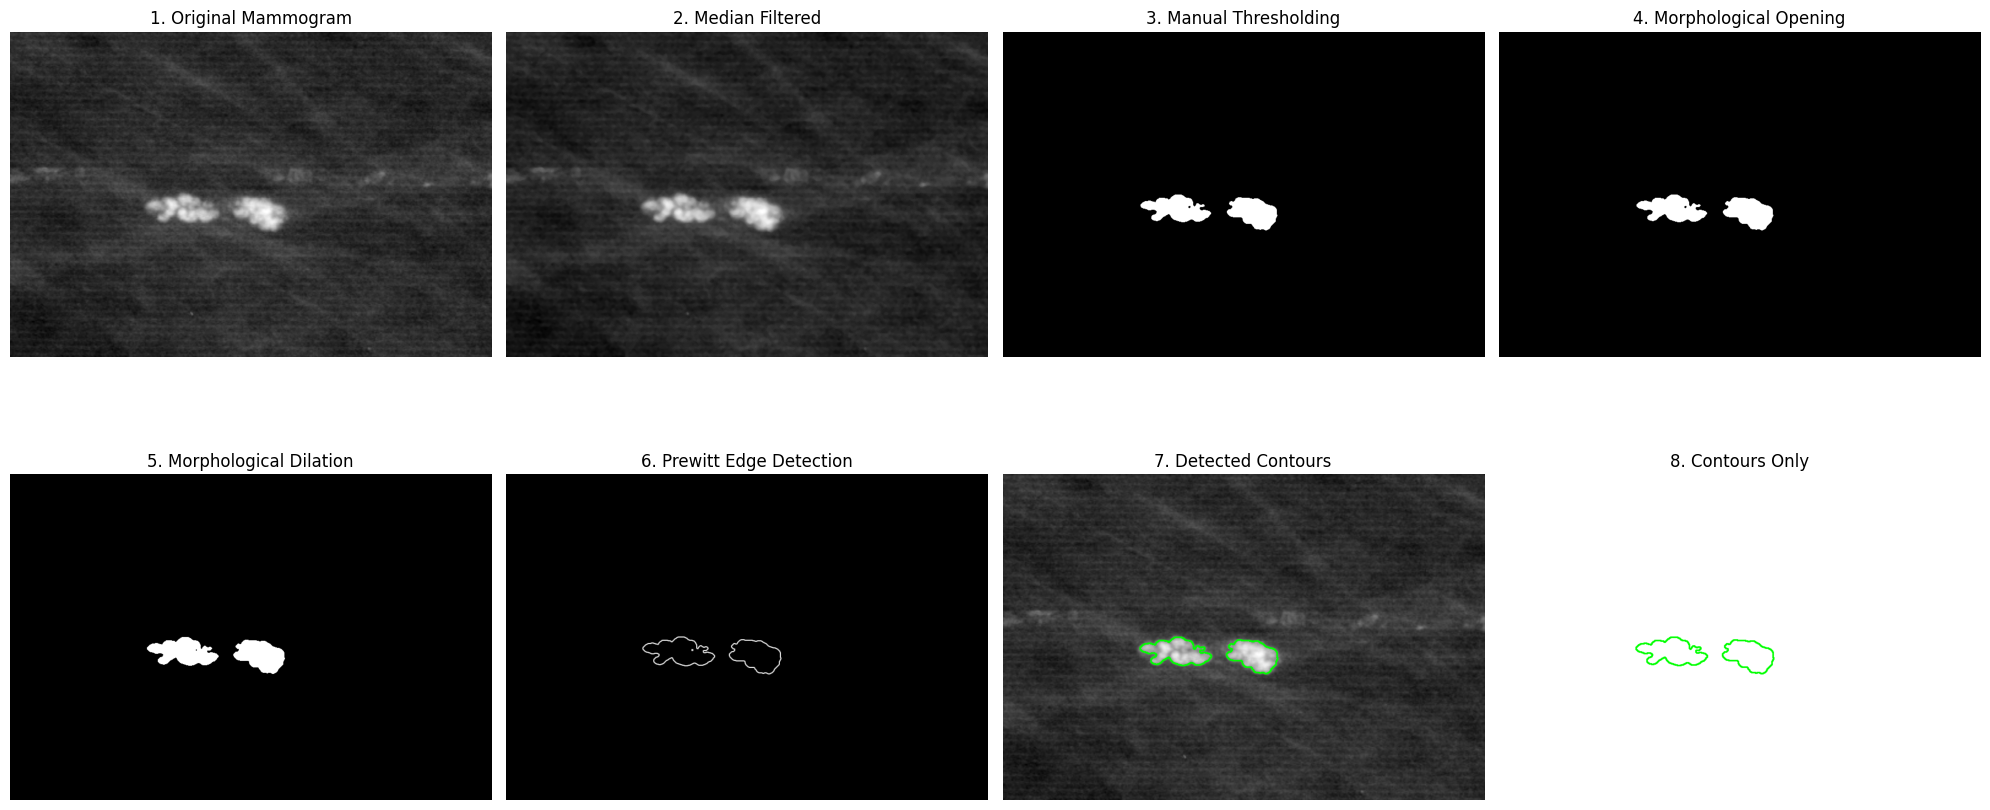

Step 1: Image loaded and resized
Step 2: Median filter applied
Step 3: Manual thresholding applied (threshold: 135)
Step 4: Morphological opening applied
Step 6: Prewitt edge detection applied
Step 7: Found 2 contours
   ✅ Prédit: BENIGN
   📊 Vérité: BENIGN
   🎯 Confiance: 0.621
   🏆 PRÉDICTION CORRECTE!


📊 RAPPORT DÉTAILLÉ DES PERFORMANCES DE PRÉDICTION
📈 PRÉCISION GLOBALE: 100.0%
📊 DÉTAIL DES RÉSULTATS:
   • Prédictions totales: 1
   • Prédictions valides: 1
   ✅ Correctes: 1
   ❌ Incorrectes: 0
   ⚠️  Faux positifs: 0
   🚨 Faux négatifs: 0

🔍 DÉTAIL PAR IMAGE:
--------------------------------------------------------------------------------
✅ /kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.171801086911287112028924051671538285833/1-112.jpg
   Prédit: BENIGN | Vérité: BENIGN | Confiance: 0.621

💾 Résultats détaillés sauvegardés dans 'predictions_with_validation_and_visualization.csv'
🎉 PRÉDICTIONS AVEC VISUALISATION TERMINÉES!


In [68]:
import pandas as pd
import numpy as np
import cv2
from scipy import stats
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

class PredictionPipelineWithValidation:
    def __init__(self, model_path, feature_extractor, ground_truth_df):
        """
        Pipeline de prédiction avec validation contre les vérités terrain
        
        Args:
            model_path: Chemin vers le modèle sauvegardé
            feature_extractor: Instance de ComprehensiveFeatureExtractor
            ground_truth_df: DataFrame contenant les vérités terrain (doit avoir 'image_path' et 'label')
        """
        # Charger le modèle
        self.model = joblib.load(model_path)
        self.feature_extractor = feature_extractor
        self.ground_truth_df = ground_truth_df
        
        # Features à supprimer
        self.features_to_drop = [
            'equivalent_diameter',
            'total_region_area', 
            'largest_region_area',
            'edge_strength_mean',
            'edge_strength_std'
        ]
        
    def get_ground_truth_label(self, image_path):
        """
        Récupère le label réel depuis le DataFrame ground_truth
        """
        try:
            # Chercher l'image_path dans le DataFrame
            match = self.ground_truth_df[self.ground_truth_df['image_path'] == image_path]
            
            if len(match) > 0:
                true_label = match.iloc[0]['label']
                return true_label
            else:
                print(f"⚠️  Image {image_path} non trouvée dans les données d'entraînement")
                return None
                
        except Exception as e:
            print(f"❌ Erreur lors de la récupération du label réel: {e}")
            return None
    
    def visualize_morphological_transformations(self, image_path):
        """
        Visualise toutes les étapes du pipeline de transformation morphologique
        """
        print(f"\n🔬 VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES")
        print("-" * 50)
        
        # Utiliser le détecteur pour obtenir toutes les étapes
        detector = BreastCancerDetection()
        results = detector.detect_masses_and_calcifications(image_path, threshold_value=135, visualize=True)
        
        return results
    
    def prepare_single_image_features(self, image_path, visualize_morphology=False):
        """
        Extrait les features d'une seule image pour la prédiction
        """
        if visualize_morphology:
            # Visualiser les transformations morphologiques
            self.visualize_morphological_transformations(image_path)
        
        # Extraire les features
        features = self.feature_extractor.extract_all_features(image_path)
        
        # Créer un DataFrame avec une seule ligne
        feature_dict = {key: [value] for key, value in features.items()}
        df_single = pd.DataFrame(feature_dict)
        
        # Supprimer les colonnes problématiques
        columns_to_drop = [col for col in self.features_to_drop if col in df_single.columns]
        df_single = df_single.drop(columns=columns_to_drop, errors='ignore')
        
        # Supprimer les colonnes non-numériques
        if 'image_path' in df_single.columns:
            df_single = df_single.drop('image_path', axis=1)
        if 'label' in df_single.columns:
            df_single = df_single.drop('label', axis=1)
            
        return df_single
    
    def get_expected_features(self):
        """
        Retourne la liste des features attendues par le modèle (15 features)
        """
        expected_features = [
            'area', 'perimeter', 'circularity', 'aspect_ratio', 'extent', 'solidity',
            'mean_intensity', 'std_intensity', 'max_intensity', 'min_intensity', 
            'intensity_range', 'entropy', 'skewness', 'kurtosis', 'edge_density',
            'boundary_roughness', 'n_regions', 'mean_region_area', 'region_size_variation',
            'image_width', 'image_height'
        ]
        
        # Supprimer les features problématiques
        expected_features = [f for f in expected_features if f not in self.features_to_drop]
        
        return expected_features[:15]
    
    def evaluate_prediction_accuracy(self, predicted_label, true_label):
        """
        Évalue si la prédiction est correcte
        """
        if true_label is None:
            return None, "LABEL_MANQUANT"
        
        if predicted_label == true_label:
            return True, "CORRECT"
        else:
            return False, "INCORRECT"
    
    def predict_single_image(self, image_path, threshold=0.5, visualize_morphology=False):
        """
        Fait une prédiction sur une seule image avec validation
        """
        try:
            # Extraire les features (avec visualisation optionnelle)
            features_df = self.prepare_single_image_features(image_path, visualize_morphology)
            
            # Obtenir les features attendues
            expected_features = self.get_expected_features()
            
            # Vérifier que nous avons les bonnes features
            missing_features = set(expected_features) - set(features_df.columns)
            if missing_features:
                # Ajouter les features manquantes avec des valeurs par défaut
                for feature in missing_features:
                    features_df[feature] = 0
            
            # Garder seulement les features attendues et dans le bon ordre
            features_df = features_df.reindex(columns=expected_features)
            
            # Prédire
            prediction_proba = self.model.predict_proba(features_df)[0]
            prediction_class = 1 if prediction_proba[1] >= threshold else 0
            confidence = prediction_proba[1] if prediction_class == 1 else prediction_proba[0]
            
            # Obtenir le label réel
            true_label = self.get_ground_truth_label(image_path)
            
            # Évaluer la précision
            is_correct, accuracy_status = self.evaluate_prediction_accuracy(prediction_class, true_label)
            
            # Déterminer le type d'erreur si applicable
            error_type = None
            if not is_correct and true_label is not None:
                if prediction_class == 1 and true_label == 0:
                    error_type = "FALSE_POSITIVE"  # Bénin prédit comme malin
                elif prediction_class == 0 and true_label == 1:
                    error_type = "FALSE_NEGATIVE"  # Malin prédit comme bénin
            
            return {
                'image_path': image_path,
                'prediction': prediction_class,
                'true_label': true_label,
                'probability_benign': prediction_proba[0],
                'probability_malignant': prediction_proba[1],
                'confidence': confidence,
                'diagnosis': 'MALIGNANT' if prediction_class == 1 else 'BENIGN',
                'true_diagnosis': 'MALIGNANT' if true_label == 1 else 'BENIGN' if true_label == 0 else 'INCONNU',
                'is_correct': is_correct,
                'accuracy_status': accuracy_status,
                'error_type': error_type,
                'features_used': len(features_df.columns)
            }
            
        except Exception as e:
            print(f"❌ Erreur lors de la prédiction pour {image_path}: {e}")
            return {
                'image_path': image_path,
                'prediction': None,
                'true_label': None,
                'probability_benign': None,
                'probability_malignant': None,
                'confidence': None,
                'diagnosis': 'ERROR',
                'true_diagnosis': 'ERROR',
                'is_correct': None,
                'accuracy_status': 'ERROR',
                'error_type': str(e),
                'features_used': 0
            }
    
    def predict_batch(self, image_paths, threshold=0.5, visualize_first_image=True):
        """
        Fait des prédictions sur un batch d'images avec validation
        """
        results = []
        
        for i, image_path in enumerate(image_paths):
            print(f"🔍 Prédiction {i+1}/{len(image_paths)}: {image_path}")
            
            # Visualiser seulement la première image pour éviter la surcharge
            visualize_morphology = visualize_first_image and i == 0
            
            result = self.predict_single_image(image_path, threshold, visualize_morphology)
            results.append(result)
            
            # Afficher le résultat détaillé
            self._print_prediction_result(result)
            print()
        
        return pd.DataFrame(results)
    
    def _print_prediction_result(self, result):
        """
        Affiche le résultat de prédiction de manière formatée
        """
        if result['prediction'] is not None:
            # Icônes et couleurs
            if result['is_correct']:
                status_icon = "✅"
                status_color = "GREEN"
            elif result['is_correct'] is False:
                status_icon = "❌"
                status_color = "RED"
            else:
                status_icon = "⚠️"
                status_color = "YELLOW"
            
            # Affichage principal
            print(f"   {status_icon} Prédit: {result['diagnosis']}")
            print(f"   📊 Vérité: {result['true_diagnosis']}")
            print(f"   🎯 Confiance: {result['confidence']:.3f}")
            
            # Détails de précision
            if result['is_correct'] is True:
                print(f"   🏆 PRÉDICTION CORRECTE!")
            elif result['is_correct'] is False:
                print(f"   💥 ERREUR: {result['error_type']}")
            else:
                print(f"   🔍 Statut: {result['accuracy_status']}")
                
        else:
            print(f"   ❌ Erreur: {result.get('error_type', 'Unknown error')}")
    
    def get_performance_summary(self, results_df):
        """
        Génère un résumé des performances des prédictions
        """
        valid_results = results_df[results_df['is_correct'].notna()]
        
        if len(valid_results) == 0:
            return "Aucune prédiction valide pour analyse"
        
        correct_predictions = valid_results[valid_results['is_correct'] == True]
        incorrect_predictions = valid_results[valid_results['is_correct'] == False]
        
        total_valid = len(valid_results)
        accuracy = len(correct_predictions) / total_valid if total_valid > 0 else 0
        
        # Analyse des erreurs
        false_positives = len(valid_results[valid_results['error_type'] == 'FALSE_POSITIVE'])
        false_negatives = len(valid_results[valid_results['error_type'] == 'FALSE_NEGATIVE'])
        
        summary = {
            'total_predictions': len(results_df),
            'valid_predictions': total_valid,
            'correct_predictions': len(correct_predictions),
            'incorrect_predictions': len(incorrect_predictions),
            'accuracy': accuracy,
            'false_positives': false_positives,
            'false_negatives': false_negatives
        }
        
        return summary
    
    def print_detailed_report(self, results_df):
        """
        Affiche un rapport détaillé des performances
        """
        print("\n" + "="*80)
        print("📊 RAPPORT DÉTAILLÉ DES PERFORMANCES DE PRÉDICTION")
        print("="*80)
        
        summary = self.get_performance_summary(results_df)
        
        if isinstance(summary, str):
            print(summary)
            return
        
        print(f"📈 PRÉCISION GLOBALE: {summary['accuracy']:.1%}")
        print(f"📊 DÉTAIL DES RÉSULTATS:")
        print(f"   • Prédictions totales: {summary['total_predictions']}")
        print(f"   • Prédictions valides: {summary['valid_predictions']}")
        print(f"   ✅ Correctes: {summary['correct_predictions']}")
        print(f"   ❌ Incorrectes: {summary['incorrect_predictions']}")
        print(f"   ⚠️  Faux positifs: {summary['false_positives']}")
        print(f"   🚨 Faux négatifs: {summary['false_negatives']}")
        
        # Détail par image
        print(f"\n🔍 DÉTAIL PAR IMAGE:")
        print("-" * 80)
        
        for _, result in results_df.iterrows():
            if result['is_correct'] is not None:
                status = "✅" if result['is_correct'] else "❌"
                print(f"{status} {result['image_path']}")
                print(f"   Prédit: {result['diagnosis']} | Vérité: {result['true_diagnosis']} | Confiance: {result['confidence']:.3f}")
                if not result['is_correct']:
                    print(f"   💥 Type d'erreur: {result['error_type']}")

# 🚀 CODE D'UTILISATION COMPLET AVEC VISUALISATION

def main_with_validation_and_visualization():
    """
    Pipeline complet avec validation des prédictions ET visualisation morphologique
    """
    # 1. Initialiser l'extracteur de features
    feature_extractor = ComprehensiveFeatureExtractor()
    
    # 2. Initialiser le pipeline avec validation
    model_path = "/kaggle/input/svm/scikitlearn/default/1/best_model.pkl"
    predictor = PredictionPipelineWithValidation(model_path, feature_extractor, df1)
    
    # 3. Liste des images à prédire (doivent être dans df1)
    image_paths = [
        "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.171801086911287112028924051671538285833/1-112.jpg"
        
        # Ajoutez d'autres chemins d'images qui sont dans df1...
    ]
    
    # Vérifier quelles images sont dans df1
    available_images = []
    for img_path in image_paths:
        if img_path in df1['image_path'].values:
            available_images.append(img_path)
        else:
            print(f"⚠️  Image non trouvée dans df1: {img_path}")
    
    print("🚀 DÉMARRAGE DES PRÉDICTIONS AVEC VALIDATION ET VISUALISATION...")
    print(f"Images à analyser: {len(available_images)}/{len(image_paths)} trouvées dans df1")
    
    if not available_images:
        print("❌ Aucune image valide trouvée dans df1")
        return None
    
    # Prédiction par lot avec validation et visualisation de la première image
    print("\n📊 PRÉDICTION AVEC VALIDATION ET VISUALISATION:")
    print("-" * 50)
    batch_results = predictor.predict_batch(available_images, visualize_first_image=True)
    
    # Générer le rapport de performance
    predictor.print_detailed_report(batch_results)
    
    # Sauvegarder les résultats détaillés
    batch_results.to_csv("predictions_with_validation_and_visualization.csv", index=False)
    print(f"\n💾 Résultats détaillés sauvegardés dans 'predictions_with_validation_and_visualization.csv'")
    
    return batch_results

# Version pour tester rapidement une seule image avec visualisation complète
def quick_test_with_visualization(image_path, model_path, ground_truth_df):
    """
    Test rapide d'une seule image avec validation ET visualisation morphologique
    """
    feature_extractor = ComprehensiveFeatureExtractor()
    predictor = PredictionPipelineWithValidation(model_path, feature_extractor, ground_truth_df)
    
    print("🎨 LANCEMENT DE LA VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES...")
    
    # Faire la prédiction avec visualisation
    result = predictor.predict_single_image(image_path, visualize_morphology=True)
    
    print("\n" + "="*70)
    print("🎯 RÉSULTAT DE PRÉDICTION AVEC VALIDATION")
    print("="*70)
    
    if result['prediction'] is not None:
        print(f"📁 Image: {result['image_path']}")
        print(f"🔮 Prédiction: {result['diagnosis']} (confiance: {result['confidence']:.3f})")
        print(f"📊 Vérité terrain: {result['true_diagnosis']}")
        
        if result['is_correct']:
            print("✅ 🎉 PRÉDICTION CORRECTE! 🎉")
        elif result['is_correct'] is False:
            print(f"❌ PRÉDICTION INCORRECTE - {result['error_type']}")
        else:
            print("⚠️  Impossible de valider (label manquant)")
            
        # Afficher les probabilités détaillées
        print(f"\n📈 PROBABILITÉS DÉTAILLÉES:")
        print(f"   • Bénin: {result['probability_benign']:.3f}")
        print(f"   • Malin: {result['probability_malignant']:.3f}")
        print(f"   • Seuil utilisé: 0.5")
        
    else:
        print("❌ Erreur lors de la prédiction")
    
    return result

# Fonction pour analyser une image spécifique avec visualisation avancée
def analyze_single_image_detailed(image_path, model_path, ground_truth_df):
    """
    Analyse détaillée d'une seule image avec visualisations complètes
    """
    feature_extractor = ComprehensiveFeatureExtractor()
    predictor = PredictionPipelineWithValidation(model_path, feature_extractor, ground_truth_df)
    
    print("🔬 ANALYSE DÉTAILLÉE D'UNE IMAGE")
    print("="*60)
    
    # 1. Visualiser les transformations morphologiques
    print("\n📊 ÉTAPE 1: VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES")
    morphological_results = predictor.visualize_morphological_transformations(image_path)
    
    # 2. Faire la prédiction
    print("\n🤖 ÉTAPE 2: PRÉDICTION AVEC LE MODÈLE IA")
    prediction_result = predictor.predict_single_image(image_path, visualize_morphology=False)
    
    # 3. Afficher le résultat final
    print("\n📋 ÉTAPE 3: SYNTHÈSE DES RÉSULTATS")
    print("-" * 40)
    
    if prediction_result['prediction'] is not None:
        # Créer une visualisation finale des résultats
        plt.figure(figsize=(12, 4))
        
        # Graphique des probabilités
        plt.subplot(1, 2, 1)
        probabilities = [prediction_result['probability_benign'], prediction_result['probability_malignant']]
        labels = ['Bénin', 'Malin']
        colors = ['green', 'red']
        
        bars = plt.bar(labels, probabilities, color=colors, alpha=0.7)
        plt.title('Probabilités de Prédiction')
        plt.ylabel('Probabilité')
        plt.ylim(0, 1)
        
        # Ajouter les valeurs sur les barres
        for bar, prob in zip(bars, probabilities):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{prob:.3f}', ha='center', va='bottom')
        
        # Graphique de validation
        plt.subplot(1, 2, 2)
        if prediction_result['is_correct'] is not None:
            status = 'Correct' if prediction_result['is_correct'] else 'Incorrect'
            color = 'green' if prediction_result['is_correct'] else 'red'
            plt.bar(['Prédiction'], [1], color=color, alpha=0.7)
            plt.title(f'Validation: {status}')
            plt.ylim(0, 1.2)
            plt.text(0, 0.5, status, ha='center', va='center', fontsize=12, fontweight='bold')
        else:
            plt.bar(['Prédiction'], [1], color='gray', alpha=0.7)
            plt.title('Validation: Indéterminée')
            plt.ylim(0, 1.2)
            plt.text(0, 0.5, 'Indéterminée', ha='center', va='center', fontsize=12)
        
        plt.tight_layout()
        plt.show()
        
        # Résumé textuel
        print(f"\n📝 RÉSUMÉ FINAL:")
        print(f"   • Diagnostic prédit: {prediction_result['diagnosis']}")
        print(f"   • Vérité terrain: {prediction_result['true_diagnosis']}")
        print(f"   • Confiance: {prediction_result['confidence']:.3f}")
        print(f"   • Statut: {'✅ CORRECT' if prediction_result['is_correct'] else '❌ INCORRECT' if prediction_result['is_correct'] is False else '⚠️ INDÉTERMINÉ'}")
        
        if prediction_result['error_type']:
            print(f"   • Type d'erreur: {prediction_result['error_type']}")
    
    return prediction_result

# Exécution principale
if __name__ == "__main__":
    print("🎨 DÉMARRAGE DES PRÉDICTIONS AVEC VISUALISATION MORPHOLOGIQUE")
    
    # Option 1: Pipeline complet avec visualisation
    results = main_with_validation_and_visualization()
    
    # Option 2: Test rapide d'une image avec visualisation
    # image_test = "/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.171801086911287112028924051671538285833/1-112.jpg"
    # single_result = quick_test_with_visualization(image_test, "/kaggle/input/svm/scikitlearn/default/1/best_model.pkl", df1)
    
    # Option 3: Analyse détaillée d'une image
    # detailed_result = analyze_single_image_detailed(image_test, "/kaggle/input/svm/scikitlearn/default/1/best_model.pkl", df1)
    
    print("🎉 PRÉDICTIONS AVEC VISUALISATION TERMINÉES!")

🔬 ANALYSE DÉTAILLÉE D'UNE IMAGE

📊 ÉTAPE 1: VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES

🔬 VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES
--------------------------------------------------
Step 1: Image loaded and resized
Step 2: Median filter applied
Step 3: Manual thresholding applied (threshold: 135)
Step 4: Morphological opening applied
Step 6: Prewitt edge detection applied
Step 7: Found 2 contours


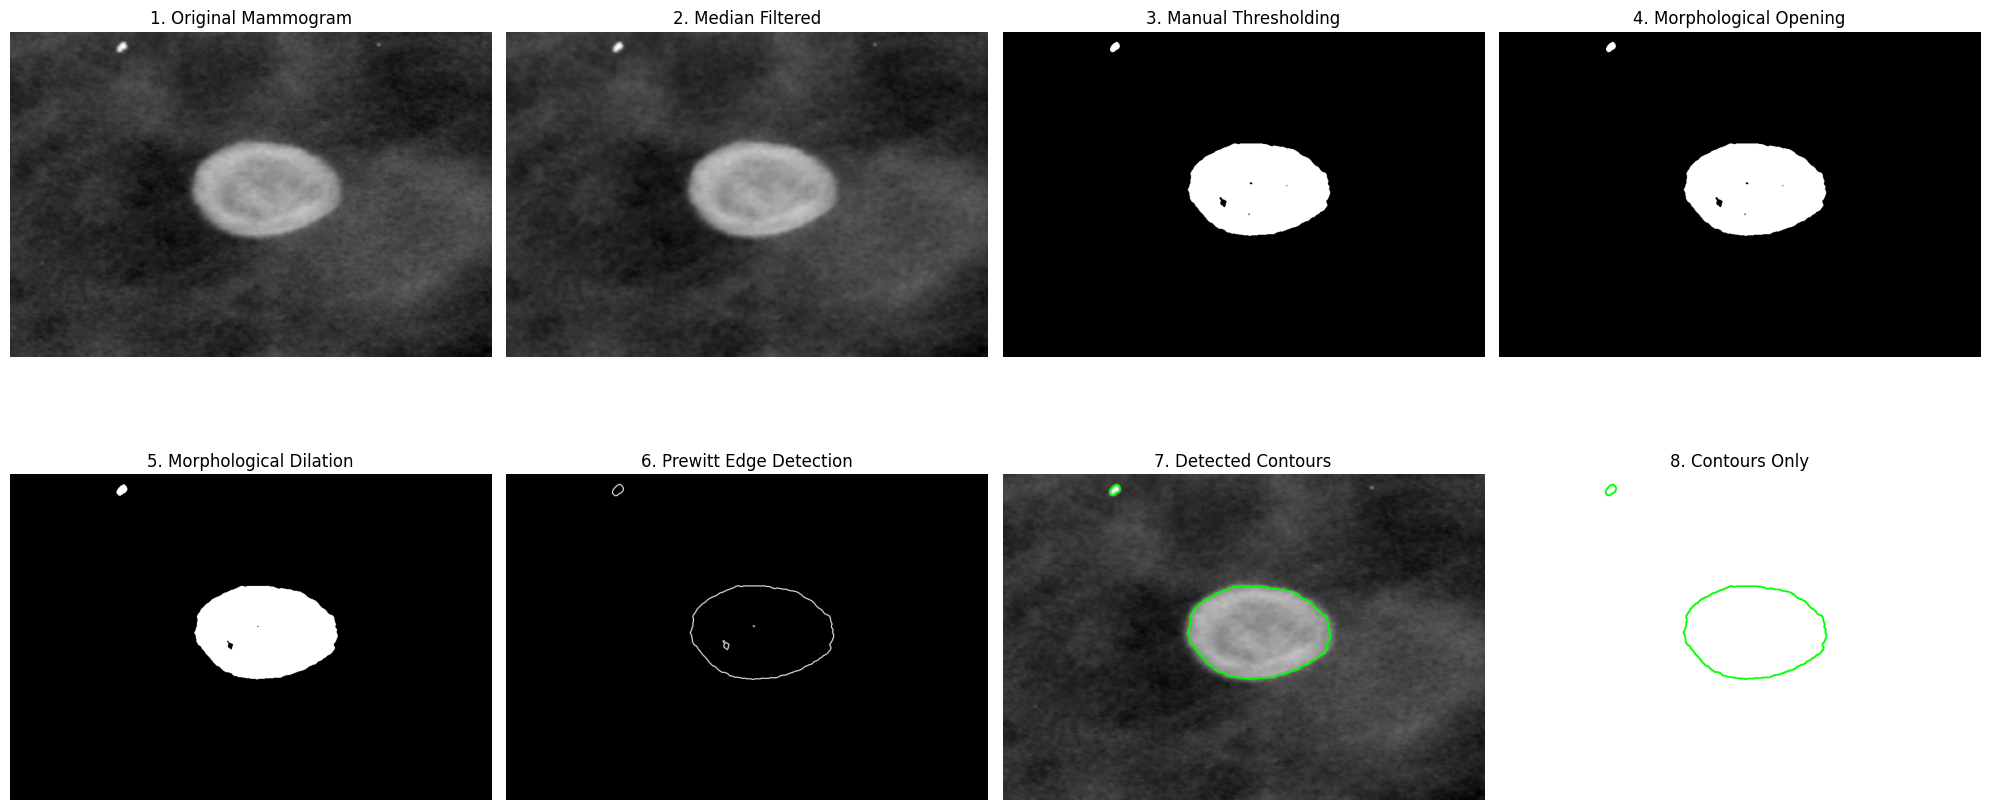


🤖 ÉTAPE 2: PRÉDICTION AVEC LE MODÈLE IA
Step 1: Image loaded and resized
Step 2: Median filter applied
Step 3: Manual thresholding applied (threshold: 135)
Step 4: Morphological opening applied
Step 6: Prewitt edge detection applied
Step 7: Found 2 contours

📋 ÉTAPE 3: SYNTHÈSE DES RÉSULTATS
----------------------------------------


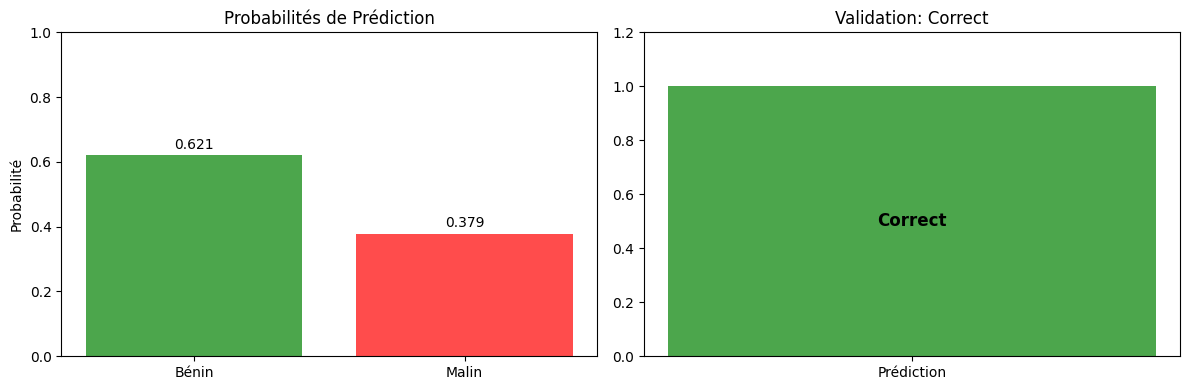


📝 RÉSUMÉ FINAL:
   • Diagnostic prédit: BENIGN
   • Vérité terrain: BENIGN
   • Confiance: 0.621
   • Statut: ✅ CORRECT


In [69]:
result = analyze_single_image_detailed(
    image_path="/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.235808582710559834528581958632991770614/1-286.jpg",
    model_path="/kaggle/input/svm/scikitlearn/default/1/best_model.pkl", 
    ground_truth_df=df1
)

🔬 ANALYSE DÉTAILLÉE D'UNE IMAGE

📊 ÉTAPE 1: VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES

🔬 VISUALISATION DES TRANSFORMATIONS MORPHOLOGIQUES
--------------------------------------------------
Step 1: Image loaded and resized
Step 2: Median filter applied
Step 3: Manual thresholding applied (threshold: 135)
Step 4: Morphological opening applied
Step 6: Prewitt edge detection applied
Step 7: Found 12 contours


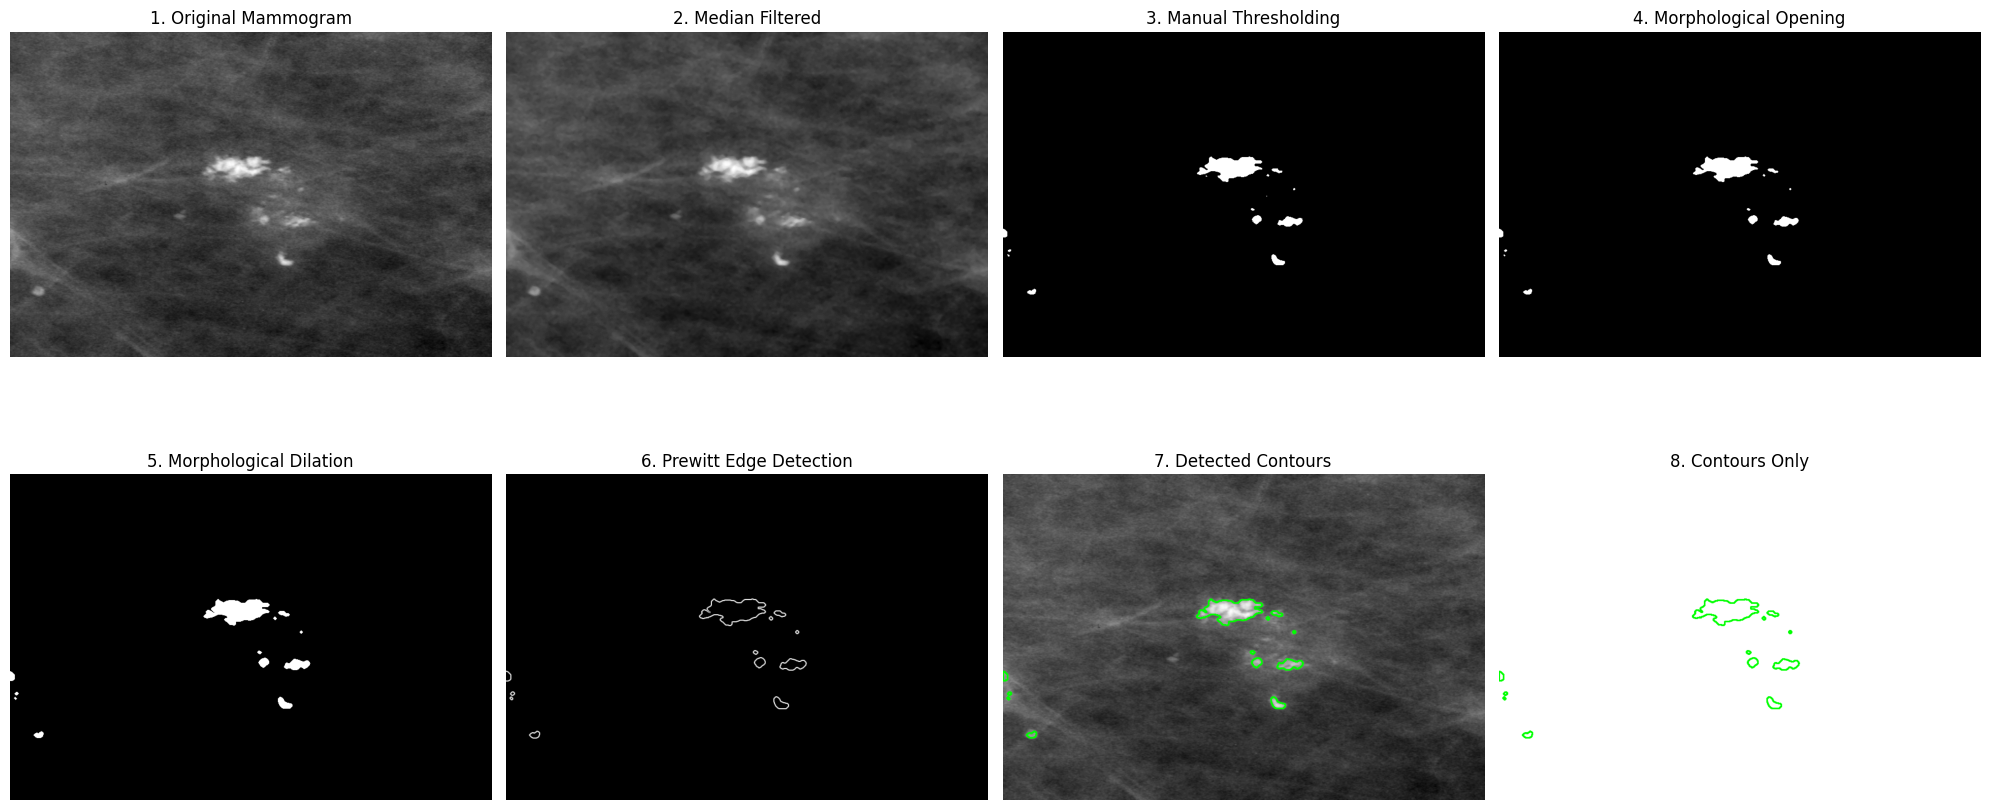


🤖 ÉTAPE 2: PRÉDICTION AVEC LE MODÈLE IA
Step 1: Image loaded and resized
Step 2: Median filter applied
Step 3: Manual thresholding applied (threshold: 135)
Step 4: Morphological opening applied
Step 6: Prewitt edge detection applied
Step 7: Found 12 contours

📋 ÉTAPE 3: SYNTHÈSE DES RÉSULTATS
----------------------------------------


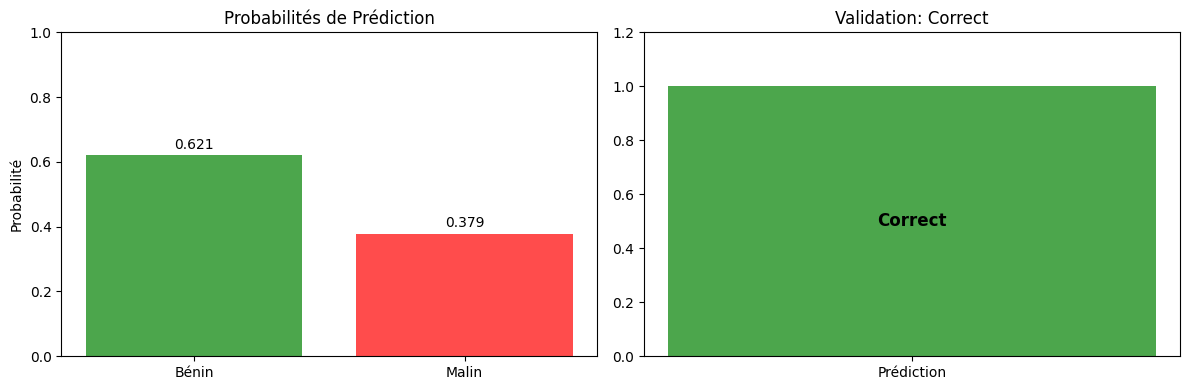


📝 RÉSUMÉ FINAL:
   • Diagnostic prédit: BENIGN
   • Vérité terrain: BENIGN
   • Confiance: 0.621
   • Statut: ✅ CORRECT


In [70]:

result = analyze_single_image_detailed(
    image_path="/kaggle/input/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.157116530711532101331849985914007772305/1-187.jpg",
    model_path="/kaggle/input/svm/scikitlearn/default/1/best_model.pkl", 
    ground_truth_df=df1
)